In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.local_feature_extractor import WindowFeatureExtractor
from src_final.features.kinematic_vocabulary import KinematicVocabulary
from src_final.models.analysis import leakage_free_residual_analysis
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_model
from src_final.models.analysis import NestedFeatureSelector

Load data and extract window features

In [72]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=True)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [01:53<00:00,  1.37s/it]


In [78]:
df_pc1_features = pd.read_csv("data/metrics/global_pc1_features.csv")
df_pc1_features['video_id'] = df_window_features['video_id'].unique()

In [74]:
df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]

### **Start With Leaky Version Where the Clustering is Fitted on the Entire Data**

In [98]:
CLIP = 5
WITH_IDLE = False

if not WITH_IDLE:
    df_window = df_window_features[df_window_features['total_path'] >= 45].copy()
else:
    df_window = df_window_features.copy()

print("Fraction of windows removed due to idle:", 1 - len(df_window) / len(df_window_features))

Fraction of windows removed due to idle: 0.21520844248185012


In [80]:
CLIP = 5
WITH_IDLE = False

if not WITH_IDLE:
    df_window = df_bimanual[df_bimanual['total_path'] >= 45].copy()
else:
    df_window = df_bimanual.copy()

print("Fraction of windows removed due to idle:", 1 - len(df_window) / len(df_bimanual))

Fraction of windows removed due to idle: 0.22650879975828986


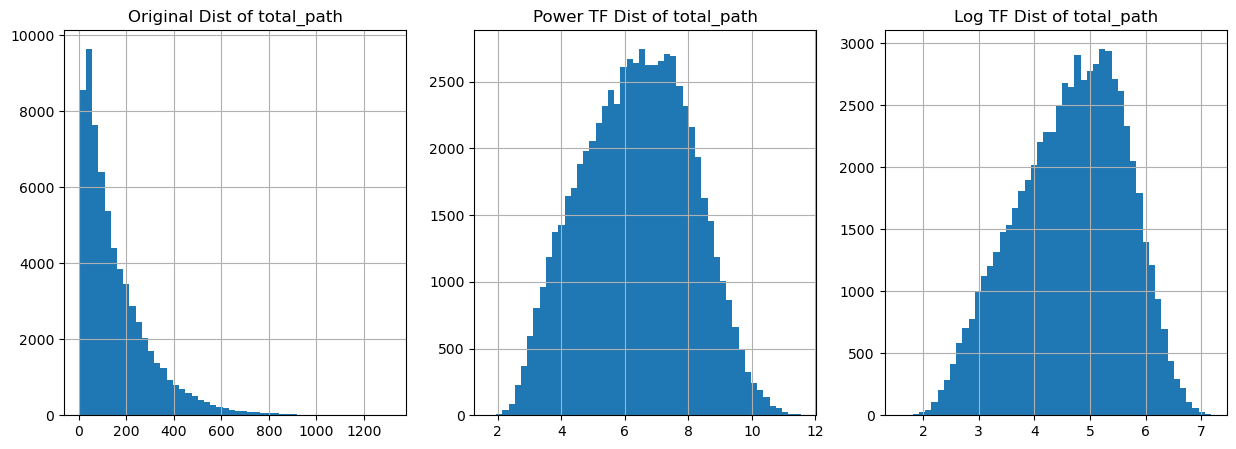

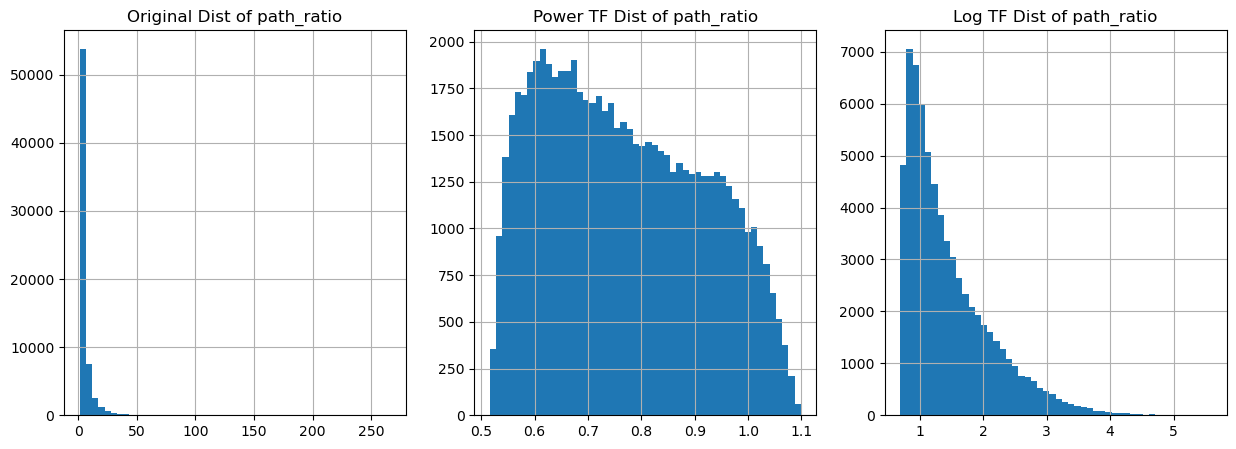

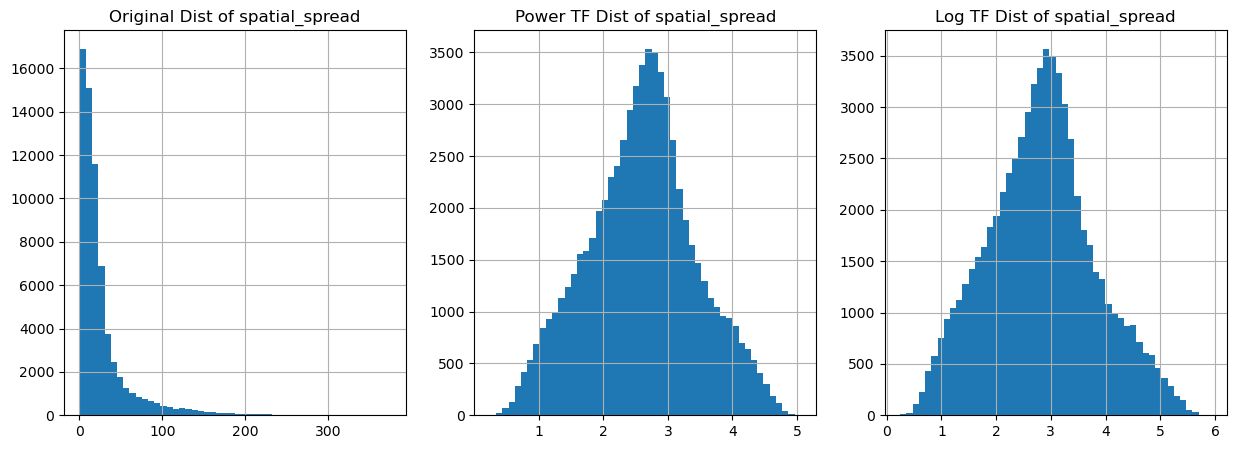

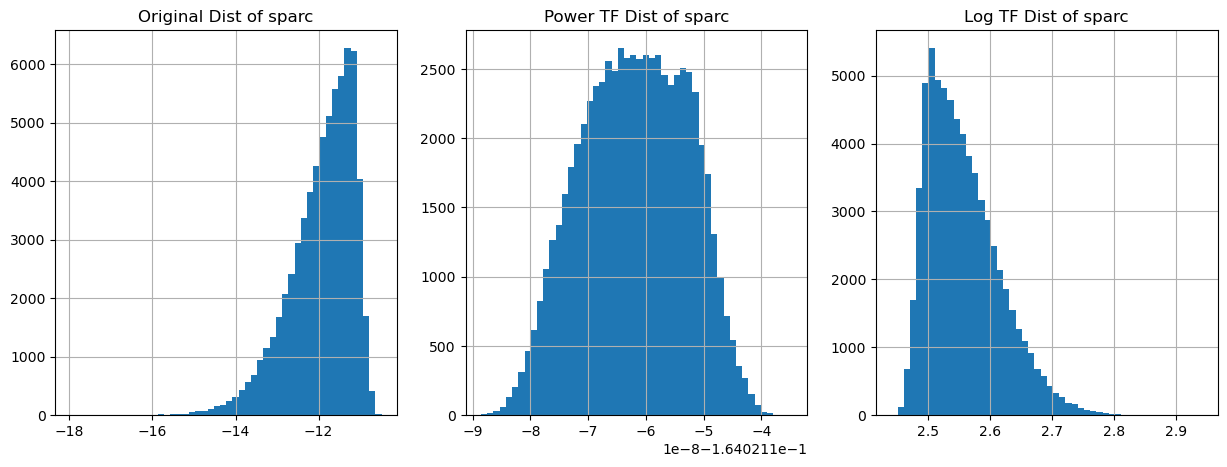

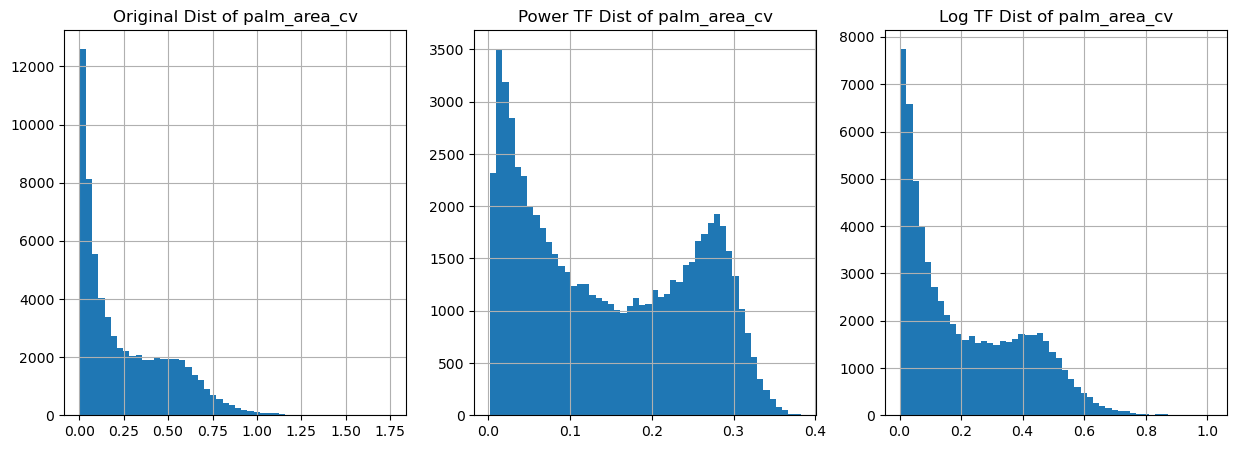

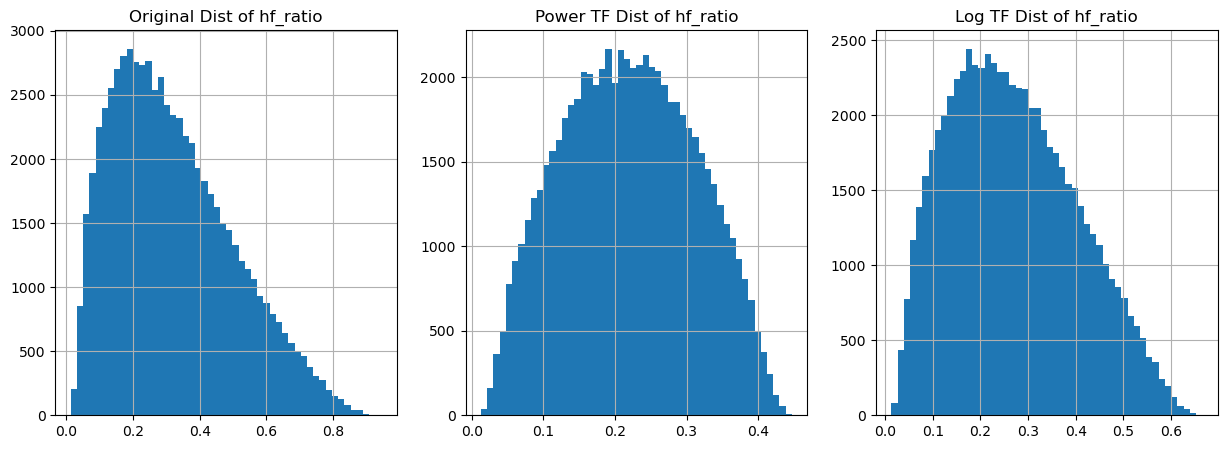

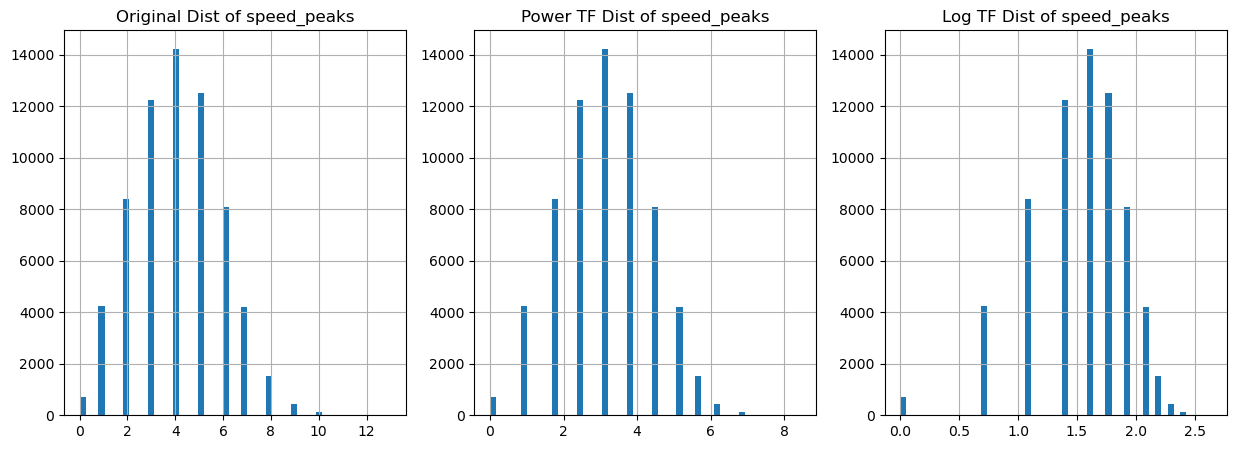

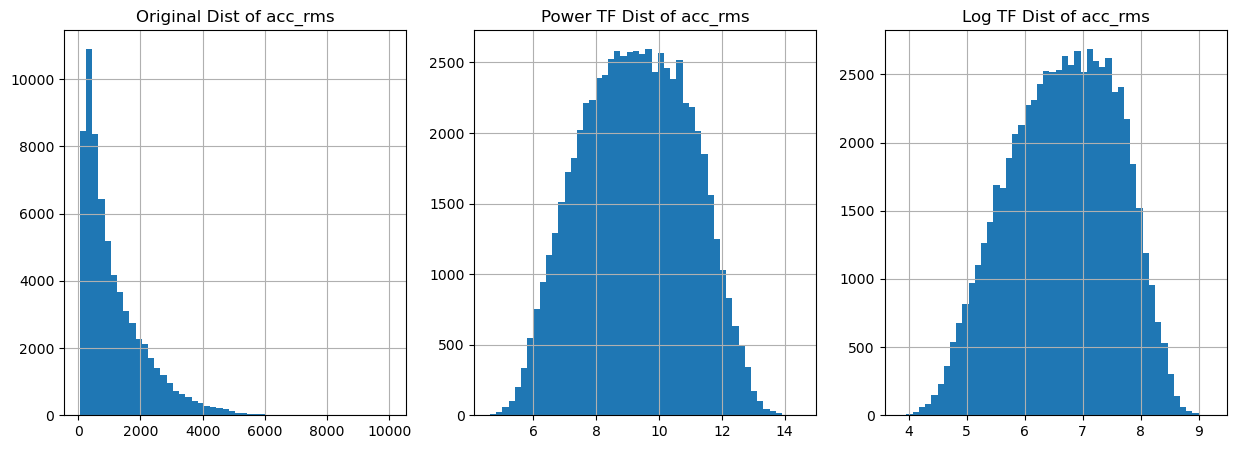

In [81]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
p_tf = PowerTransformer(method='yeo-johnson', standardize=False)

for feat in ['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'hf_ratio', 'speed_peaks', 'acc_rms']:

    X = df_window_features[feat]
    X_transformed = p_tf.fit_transform(X.values.reshape(-1, 1))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Original Dist of {feat}")
    df_window_features[feat].hist(bins=50)

    plt.subplot(1, 3, 2)
    plt.title(f"Power TF Dist of {feat}")  
    pd.Series(X_transformed.flatten()).hist(bins=50)

    plt.subplot(1, 3, 3)
    plt.title(f"Log TF Dist of {feat}")
    df_window_features[feat].apply(lambda x: np.log1p(np.abs(x))).hist(bins=50)

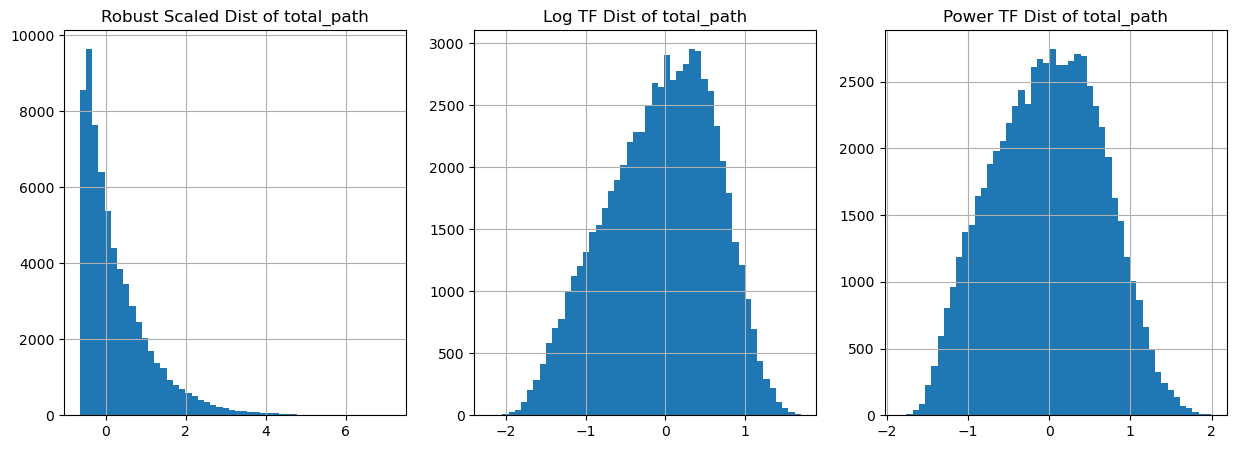

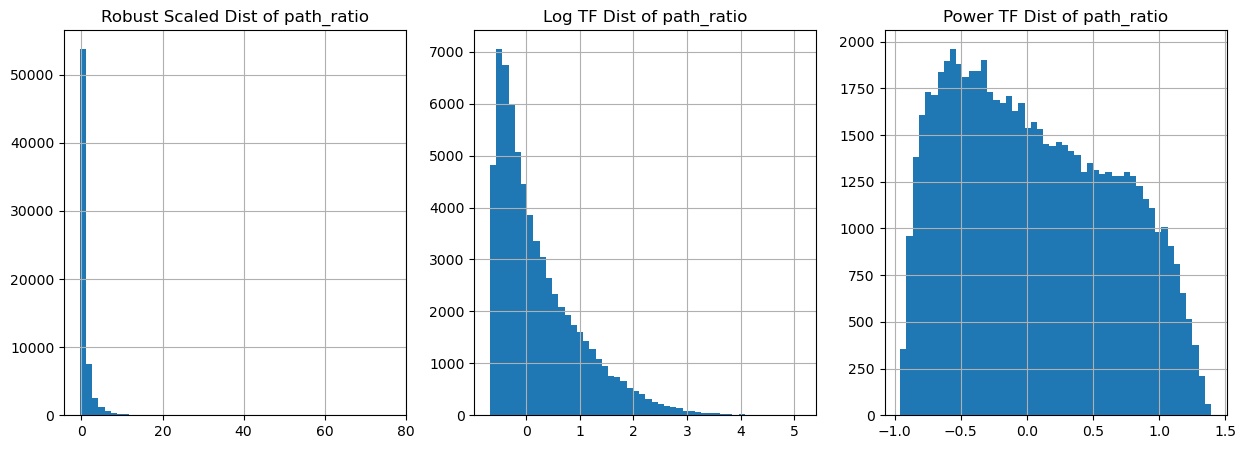

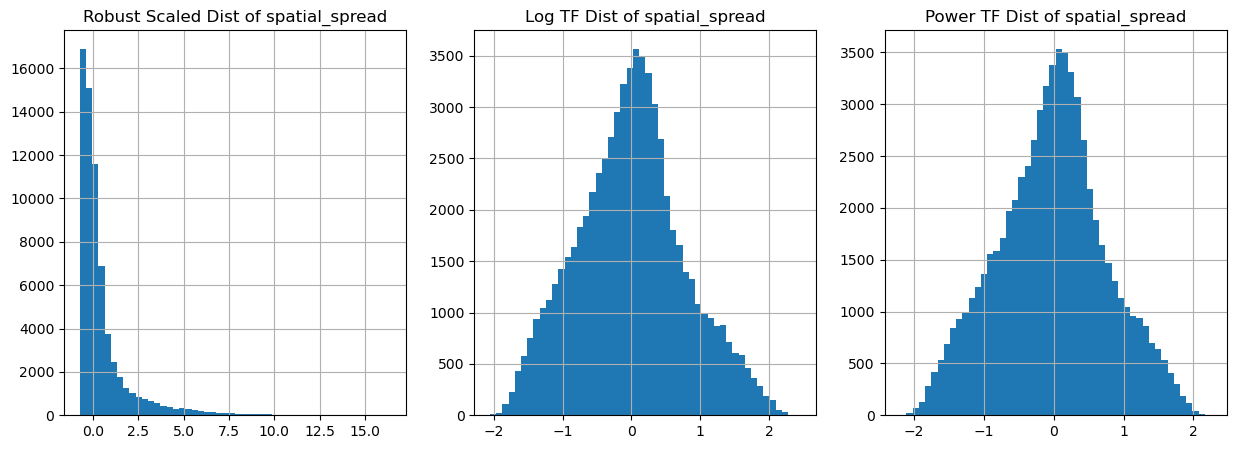

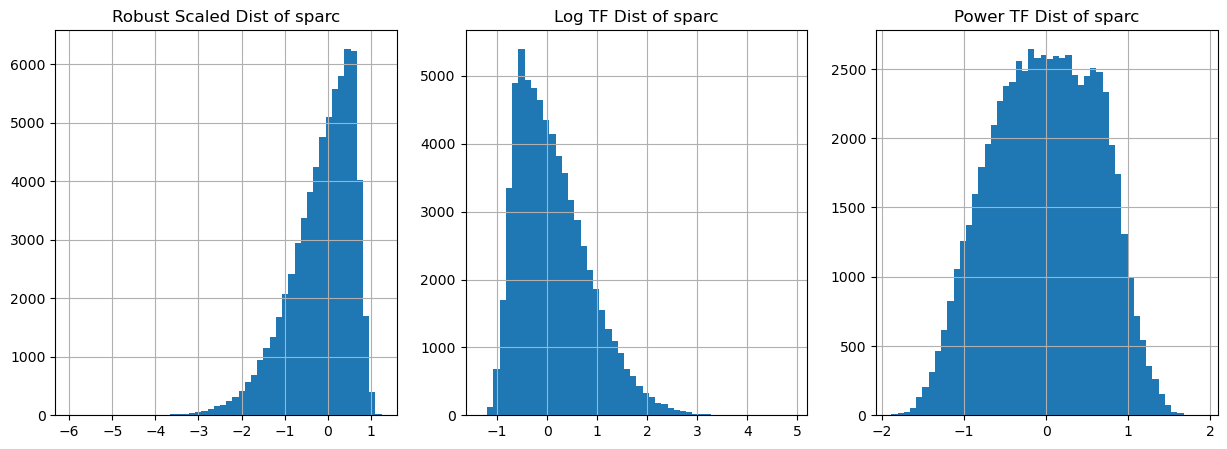

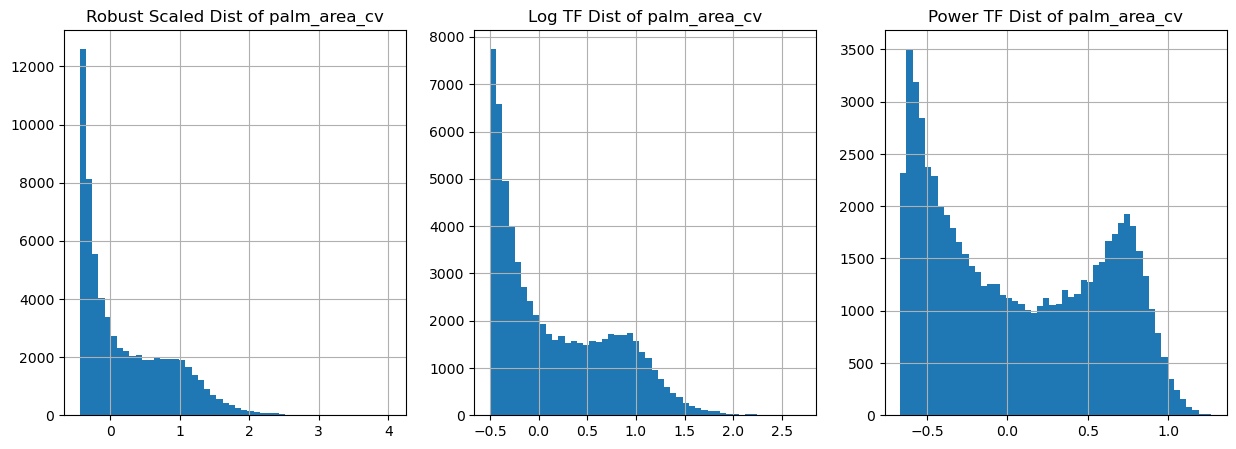

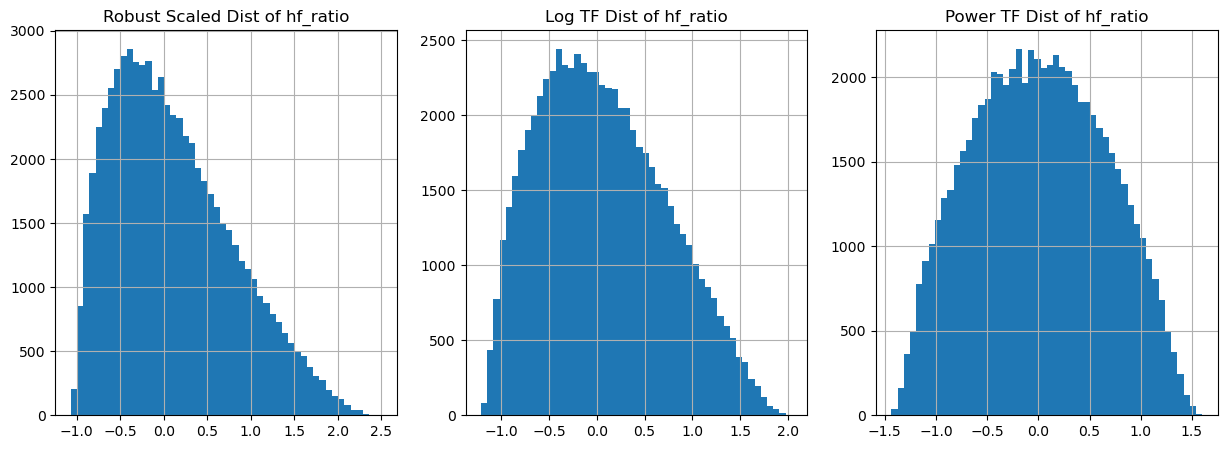

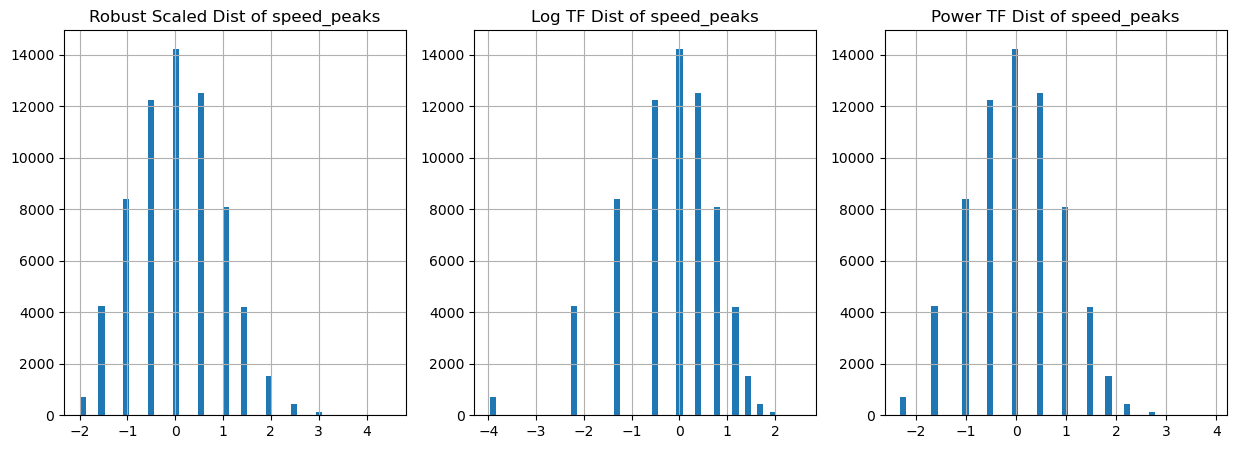

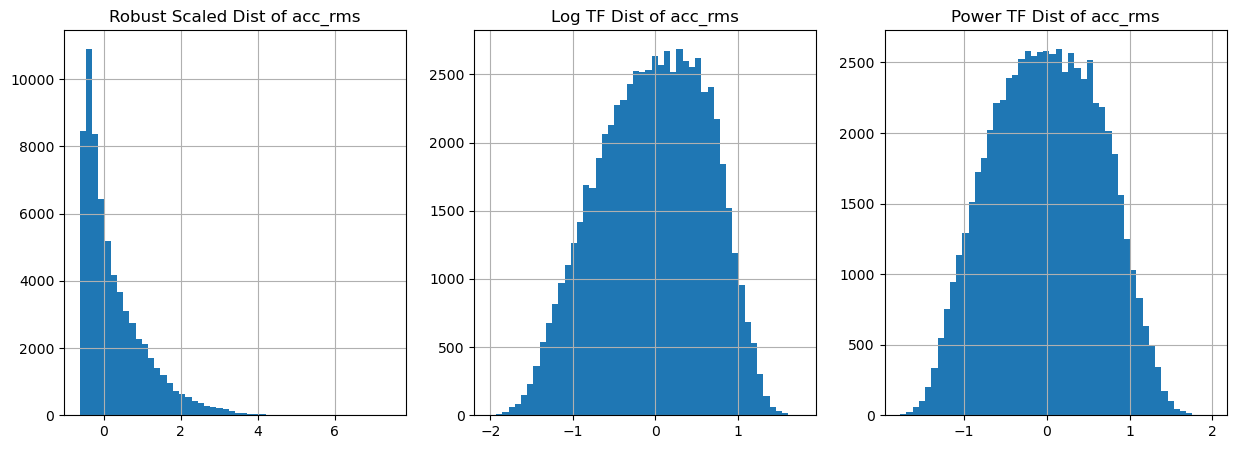

In [82]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

for feat in ['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'hf_ratio', 'speed_peaks', 'acc_rms']: #['bimanual_sync', 'bimanual_ratio', 'bimanual_dist_mean', 'bimanual_dist_std']:#

    X = df_window_features[feat]
    X_scaled = scaler.fit_transform(X.values.reshape(-1, 1))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Robust Scaled Dist of {feat}")
    pd.Series(X_scaled.flatten()).hist(bins=50)

    plt.subplot(1, 3, 2)
    plt.title(f"Log TF Dist of {feat}")
    X_tf_scaled = scaler.fit_transform(df_window_features[feat].apply(lambda x: np.log1p(np.abs(x))).values.reshape(-1, 1))
    pd.Series(X_tf_scaled.flatten()).hist(bins=50)

    plt.subplot(1, 3, 3)
    plt.title(f"Power TF Dist of {feat}")
    X_tf_scaled = scaler.fit_transform(p_tf.fit_transform(X.values.reshape(-1, 1)))
    pd.Series(X_tf_scaled.flatten()).hist(bins=50)

In [83]:
# intercorrelation of features
feature_cols = [col for col in df_window.columns if col not in ['video_id', 'participant_id', 'window_start_frame', 'is_idle']]
corr_matrix = df_window[feature_cols].corr()
corr_matrix

# => vel_p90 is redundant with total_path

,total_path,path_ratio,spatial_spread,sparc,hf_ratio,speed_peaks,acc_rms,palm_area_cv,bimanual_dist_mean,bimanual_dist_std,bimanual_sync,bimanual_ratio
total_path,1.000000,0.124865,0.827145,0.129512,-0.052595,-0.191172,0.828878,0.382105,0.079642,0.601078,0.147294,0.266594
path_ratio,0.124865,1.000000,-0.175617,-0.191808,0.394734,0.332553,0.323448,0.210762,-0.007202,-0.156325,-0.160431,0.243349
spatial_spread,0.827145,-0.175617,1.000000,0.302167,-0.408709,-0.450150,0.462827,0.173278,0.086533,0.708893,0.260708,0.049463
sparc,0.129512,-0.191808,0.302167,1.000000,-0.566691,-0.492307,-0.013042,-0.075468,0.055297,0.230202,0.167406,-0.071278
hf_ratio,-0.052595,0.394734,-0.408709,-0.566691,1.000000,0.699965,0.238539,0.184817,-0.067005,-0.331060,-0.233541,0.207838
speed_peaks,-0.191172,0.332553,-0.450150,-0.492307,0.699965,1.000000,0.107159,0.147536,-0.103914,-0.352147,-0.299946,0.148770
acc_rms,0.828878,0.323448,0.462827,-0.013042,0.238539,0.107159,1.000000,0.467646,0.038435,0.361052,-0.009341,0.397916
palm_area_cv,0.382105,0.210762,0.173278,-0.075468,0.184817,0.147536,0.467646,1.000000,-0.107389,0.140952,-0.053842,0.204256
bimanual_dist_mean,0.079642,-0.007202,0.086533,0.055297,-0.067005,-0.103914,0.038435,-0.107389,1.000000,0.073847,-0.053180,0.165483
bimanual_dist_std,0.601078,-0.156325,0.708893,0.230202,-0.331060,-0.352147,0.361052,0.140952,0.073847,1.000000,0.164019,-0.163468


In [111]:
vocab = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=20,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )

"""df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
vocab = KinematicVocabulary(n_clusters=20, random_state=42, model_type='kmeans', n_init=5,
                            feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'bimanual_dist_mean', 'bimanual_sync'],
                            log_feats=['total_path', 'path_ratio', 'spatial_spread', 'sparc'])
df_window = df_bimanual.copy()"""

vocab.fit(df_window)
df_voc = vocab.transform(df_window)
df_voc.head(5)


,SurgeMe_0,SurgeMe_1,SurgeMe_2,SurgeMe_3,SurgeMe_4,SurgeMe_5,SurgeMe_6,SurgeMe_7,SurgeMe_8,SurgeMe_9,SurgeMe_10,SurgeMe_11,SurgeMe_12,SurgeMe_13,SurgeMe_14,SurgeMe_15,SurgeMe_16,SurgeMe_17
"(2024-01-15_13-18-23, 1)",0.054508,0.077275,0.056468,0.053725,0.062731,0.029674,0.053728,0.035909,0.062202,0.029729,0.047786,0.075498,0.063763,0.072314,0.048712,0.052826,0.059071,0.064082
"(2024-01-15_13-37-36, 1)",0.057987,0.071921,0.054320,0.057429,0.063894,0.037064,0.051581,0.043079,0.061041,0.030942,0.049666,0.073999,0.061844,0.070913,0.044031,0.051333,0.062368,0.056589
"(2024-01-15_14-03-23, 1)",0.048168,0.061398,0.064589,0.065853,0.052283,0.033436,0.054630,0.055514,0.057012,0.045641,0.051954,0.062541,0.066566,0.055811,0.041361,0.074404,0.056183,0.052657
"(2024-01-15_14-32-45, 2)",0.060407,0.079732,0.053717,0.050059,0.072000,0.031750,0.059153,0.030444,0.059246,0.025581,0.052559,0.082243,0.064393,0.079921,0.039087,0.047195,0.056772,0.055741
"(2024-01-15_15-05-31, 2)",0.060487,0.077882,0.055342,0.049530,0.073896,0.028689,0.059292,0.028231,0.063959,0.025167,0.051744,0.080215,0.066481,0.081127,0.040392,0.046322,0.056435,0.054806


In [112]:
candidate_features = [col for col in df_voc.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_voc[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]  
for idx in top_pearson_indices:
    print(f"{features[idx]}: Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
SurgeMe_11: Pearson r = -0.5000, Spearman rho = -0.4833
SurgeMe_16: Pearson r = -0.4984, Spearman rho = -0.4759
SurgeMe_15: Pearson r = 0.4825, Spearman rho = 0.4754
SurgeMe_1: Pearson r = -0.4813, Spearman rho = -0.4424
SurgeMe_7: Pearson r = 0.4540, Spearman rho = 0.4631
SurgeMe_9: Pearson r = 0.3965, Spearman rho = 0.4481
SurgeMe_13: Pearson r = -0.3707, Spearman rho = -0.3724
SurgeMe_17: Pearson r = -0.3387, Spearman rho = -0.2660
SurgeMe_3: Pearson r = 0.3309, Spearman rho = 0.3164
SurgeMe_4: Pearson r = -0.2684, Spearman rho = -0.2581
SurgeMe_0: Pearson r = -0.2654, Spearman rho = -0.2692
SurgeMe_2: Pearson r = 0.2626, Spearman rho = 0.2711


In [113]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-9:]
top_2_negative = np.argsort(pearson_corrs)[:9]
if vocab.model_type == 'kmeans':
    centroids = vocab.model.cluster_centers_
else:
    centroids = vocab.model.means_
feature_names = vocab.feature_cols

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 11, (corr: -0.5): {'path_ratio': np.float64(-0.2), 'spatial_spread': np.float64(0.08), 'palm_area_cv': np.float64(-0.38), 'sparc': np.float64(0.36)}
Cluster 16, (corr: -0.498): {'path_ratio': np.float64(-0.18), 'spatial_spread': np.float64(0.98), 'palm_area_cv': np.float64(0.25), 'sparc': np.float64(0.6)}
Cluster 1, (corr: -0.481): {'path_ratio': np.float64(-0.32), 'spatial_spread': np.float64(0.54), 'palm_area_cv': np.float64(-0.31), 'sparc': np.float64(-0.47)}
Cluster 13, (corr: -0.371): {'path_ratio': np.float64(-0.25), 'spatial_spread': np.float64(-0.27), 'palm_area_cv': np.float64(-0.44), 'sparc': np.float64(-0.48)}
Cluster 17, (corr: -0.339): {'path_ratio': np.float64(-0.39), 'spatial_spread': np.float64(1.41), 'palm_area_cv': np.float64(-0.13), 'sparc': np.float64(-0.49)}
Cluster 4, (corr: -0.268): {'path_ratio': np.float64(0.1), 'spatial_spread': np.float64(-0.79), 'palm_area_cv': np.float64(-0.46), 'sparc': np.float64(0.03)}
C

In [114]:
top_positive = [f'SurgeMe_{idx}' for idx in top_2_positive]
top_negative = [f'SurgeMe_{idx}' for idx in top_2_negative]
top = top_positive + top_negative

df_voc[top].corr()

,SurgeMe_6,SurgeMe_5,SurgeMe_10,SurgeMe_12,SurgeMe_2,SurgeMe_3,SurgeMe_9,SurgeMe_7,SurgeMe_15,SurgeMe_11,SurgeMe_16,SurgeMe_1,SurgeMe_13,SurgeMe_17,SurgeMe_4,SurgeMe_0,SurgeMe_8,SurgeMe_14
SurgeMe_6,1.000000,0.438757,0.832125,-0.219911,-0.161448,-0.226482,0.013928,-0.003944,-0.042864,0.059838,-0.727454,-0.205331,0.124741,-0.525609,0.431606,0.475208,-0.725261,-0.607875
SurgeMe_5,0.438757,1.000000,0.807985,-0.087262,-0.290878,0.319601,-0.018527,0.391287,0.138926,-0.190073,-0.504908,-0.482107,-0.232925,-0.508326,0.124951,0.400106,-0.606757,-0.444960
SurgeMe_10,0.832125,0.807985,1.000000,-0.274171,-0.315397,-0.007953,0.009446,0.234343,0.041265,-0.083875,-0.740421,-0.391643,-0.062281,-0.523241,0.334675,0.512816,-0.809526,-0.519749
SurgeMe_12,-0.219911,-0.087262,-0.274171,1.000000,0.363071,0.577828,0.057068,0.126799,0.378025,-0.330187,-0.053459,-0.317653,-0.232805,-0.417710,-0.230793,-0.325287,0.466925,-0.208770
SurgeMe_2,-0.161448,-0.290878,-0.315397,0.363071,1.000000,0.595973,0.851353,0.600095,0.812676,-0.751241,-0.030073,-0.609397,-0.754295,-0.365489,-0.825197,-0.829308,0.150680,-0.052598
SurgeMe_3,-0.226482,0.319601,-0.007953,0.577828,0.595973,1.000000,0.538589,0.791044,0.837150,-0.773234,-0.142472,-0.795550,-0.802529,-0.569351,-0.717759,-0.568032,0.027265,-0.227395
SurgeMe_9,0.013928,-0.018527,0.009446,0.057068,0.851353,0.538589,1.000000,0.810123,0.875389,-0.854359,-0.314878,-0.749460,-0.831946,-0.411056,-0.803151,-0.747370,-0.206050,-0.070707
SurgeMe_7,-0.003944,0.391287,0.234343,0.126799,0.600095,0.791044,0.810123,1.000000,0.905945,-0.891674,-0.394937,-0.878615,-0.886201,-0.529944,-0.769482,-0.607999,-0.321349,-0.166799
SurgeMe_15,-0.042864,0.138926,0.041265,0.378025,0.812676,0.837150,0.875389,0.905945,1.000000,-0.933305,-0.364761,-0.877889,-0.903153,-0.574854,-0.828886,-0.747970,-0.157247,-0.189882
SurgeMe_11,0.059838,-0.190073,-0.083875,-0.330187,-0.751241,-0.773234,-0.854359,-0.891674,-0.933305,1.000000,0.312595,0.894303,0.942288,0.451503,0.841429,0.769648,0.053109,-0.022824


In [115]:
pc1_features = [
    'angular_dir_switches_Right',
    'nmu_peaks_Right',
    'total_path_Right',
    'total_angular_path_Right',
    'ldlj_smoothness_Right'
    ]

# combine global features with aggregated window features
comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)

comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)

In [116]:
#candidate_features = [c for c in candidate_features if c not in ['palm_area_cv_p10', 'palm_area_cv_p90', 'palm_area_cv_mean', 'palm_area_cv_std', 'is_idle_p90', 'is_idle_std', 'is_idle_median', 'is_idle_p10']]
df_res_leakage_free = leakage_free_residual_analysis(comb_df, pc1_features, candidate_features, base_features=[], top_n=3, perform_shuffle=False)
df_res_leakage_free

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
8,SurgeMe_16,0.144956,0.013089,0.118736,-0.358592,1.000000
7,SurgeMe_15,0.126272,0.009844,0.101894,0.334829,1.000000
3,SurgeMe_11,0.116684,0.010690,0.095995,-0.316198,0.892857
1,SurgeMe_1,0.092182,0.011213,0.070191,-0.279880,0.000000
9,SurgeMe_17,0.088456,0.011891,0.064454,-0.292546,0.071429
15,SurgeMe_7,0.080783,0.008537,0.063923,0.265032,0.000000
4,SurgeMe_12,0.076575,0.010596,0.059154,0.275882,0.035714
17,SurgeMe_9,0.074390,0.010029,0.059353,0.261435,0.000000
11,SurgeMe_3,0.054553,0.007110,0.043317,0.227653,0.000000
10,SurgeMe_2,0.053672,0.010264,0.041171,0.229300,0.000000


LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 16.65it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7635 | MAE: 4.7054 | MAE STD: 3.7600 | R2: 0.5813 | Adj R2: 0.4180

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.938586    0.302804
1          PC1       -4.984242    0.171306
2    SurgeMe_0       -1.429991    0.219218
3    SurgeMe_1        0.000000    0.000000
4    SurgeMe_2        0.000000    0.000000
5    SurgeMe_3        0.000000    0.000000
6    SurgeMe_4        0.000000    0.000000
7    SurgeMe_5       -0.001372    0.007130
8    SurgeMe_6        0.000000    0.000000
9    SurgeMe_7        0.000000    0.000000
10   SurgeMe_8       -0.007163    0.037219
11   SurgeMe_9        0.000000    0.000000
12  SurgeMe_10        0.000000    0.000000
13  SurgeMe_11       -0.108029    0.180290
14  SurgeMe_12        0.886818    0.137995
15  SurgeMe_13        0.000000    0.000000
16  SurgeMe_14        0.000000    0.000000
17  SurgeMe_15        0.000000    0.000000
18  SurgeMe_16       -2.682498    0.159099
19  Surge

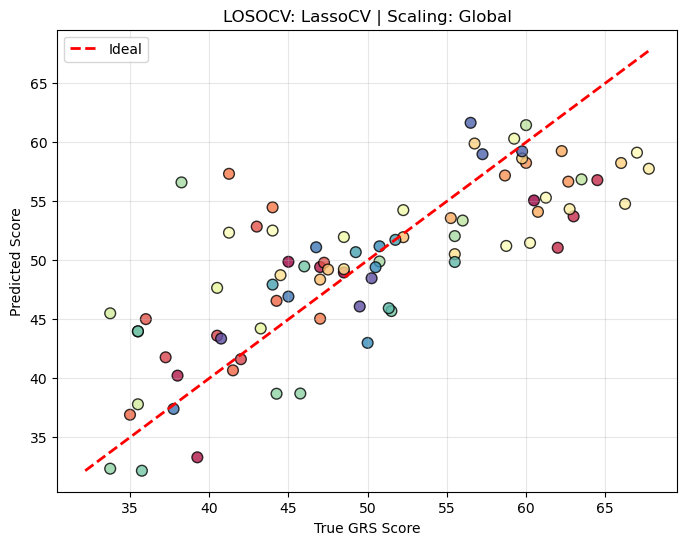

In [105]:
from src_final.models.baseline_loso import evaluate_loso_model
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, Lasso

df_case_onehot = pd.get_dummies(df_pc1_features['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in comb_df.columns):
    comb_df = pd.concat([comb_df, df_case_onehot], axis=1)
    candidate_features += list(df_case_onehot.columns)

_, _, _ = evaluate_loso_model(comb_df, 
                              pc1_features, 
                              model_class=LassoCV, 
                              model_params={'alphas': np.logspace(-1, 1, 20)}, 
                              extra_features=candidate_features, 
                              print_fold_metrics=False, 
                              pca_components=[0])

try with leakage free residual anaylsis script

In [121]:
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble, run_nested_loso

all_maes = []
all_corrs = []
all_r2s = []

for n_cluster in range(6, 30, 1):
    print("==================== N CLUSTER", n_cluster, "===================")
    vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=42, model_type='kmeans', n_init=20,
                              feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                              log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                              )

    vocab.fit(df_window)
    df_voc = vocab.transform(df_window)

    candidate_features = [col for col in df_voc.columns if col not in ['video_id']]
    comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)
    
    if not any('Case_1' in col for col in comb_df.columns):
        comb_df = pd.concat([comb_df, df_case_onehot], axis=1)
        #candidate_features += ['Case_1', 'Case_2', 'Case_3']

    res_df, _, = df_nested_results = run_nested_loso(
                    df=comb_df,
                    primary_features=pc1_features,
                    candidate_features=candidate_features,
                    extra_features=['Case_1', 'Case_3'],
                    model_type='ridge',
                    model_params={'hidden_dim': 16, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
                    top_n=3,
                    print_fold_metrics=False,
                    corr_threshold=0.8,
                    pr2_threshold=0.05
                )


    #all_maes.append(summary['Overall_MAE'])
    #all_corrs.append(summary['Overall_Spearman_R'])
    #all_r2s.append(summary['Overall_R2'])

==================== N CLUSTER 6 ===================

=== Nested LOSO Summary (ridge) ===
MAE: 5.1947 +/- 4.1851
Train MAE: 4.7115
Spearman R: 0.6929
Overall R2: 0.4864
Overall Adjusted R2: 0.4600

Feature Selection Stability:
SurgeMe_2    0.785714
Name: count, dtype: float64
==================== N CLUSTER 7 ===================

=== Nested LOSO Summary (ridge) ===
MAE: 5.2793 +/- 4.1330
Train MAE: 4.7288
Spearman R: 0.6923
Overall R2: 0.4812
Overall Adjusted R2: 0.4545

Feature Selection Stability:
SurgeMe_5    0.714286
Name: count, dtype: float64
==================== N CLUSTER 8 ===================

=== Nested LOSO Summary (ridge) ===
MAE: 5.3435 +/- 4.2684
Train MAE: 4.7479
Spearman R: 0.6784
Overall R2: 0.4601
Overall Adjusted R2: 0.4325

Feature Selection Stability:
SurgeMe_4    0.607143
SurgeMe_1    0.107143
Name: count, dtype: float64
==================== N CLUSTER 9 ===================

=== Nested LOSO Summary (ridge) ===
MAE: 4.8626 +/- 3.9069
Train MAE: 4.4411
Spearman R: 0.74

In [71]:
all_maes = []
all_corrs = []
all_r2s = []

for n_cluster in range(6, 30, 1):
    print("==================== N CLUSTER", n_cluster, "===================")
    vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=42, model_type='kmeans', n_init=20,
                              feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                              log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                              )

    vocab.fit(df_window)
    df_voc = vocab.transform(df_window)

    candidate_features = [col for col in df_voc.columns if col not in ['video_id']]
    comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)
    
    if not any('Case_1' in col for col in comb_df.columns):
        comb_df = pd.concat([comb_df, df_case_onehot], axis=1)
        #candidate_features += ['Case_1', 'Case_2', 'Case_3']

    summary, _, _ = evaluate_loso_model(comb_df, 
                                  [], 
                                  model_class=LassoCV, 
                                  model_params={'alphas': np.logspace(-1, 1, 20)}, 
                                  extra_features=candidate_features, 
                                  print_fold_metrics=False, 
                                  #pca_components=[0],
                                  plot=False,
                                  verbose=True
                                  )


    all_maes.append(summary['Overall_MAE'])
    all_corrs.append(summary['Overall_Spearman_R'])
    all_r2s.append(summary['Overall_R2'])

==================== N CLUSTER 6 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 24.95it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.3109 | MAE: 7.4790 | MAE STD: 4.5957 | R2: 0.1106 | Adj R2: 0.0276

Feature Weights:
     Feature  Average_Weight  Std_Weight
0       bias       49.938586    0.302804
1  SurgeMe_0        0.079436    0.341777
2  SurgeMe_1       -2.728354    0.448123
3  SurgeMe_2        1.033004    0.562100
4  SurgeMe_3       -0.766141    0.374821
5  SurgeMe_4       -0.026863    0.139586
6  SurgeMe_5       -0.068141    0.246192

--- Per-Fold Performance Summary ---
==================== N CLUSTER 7 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 27.85it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.3282 | MAE: 7.3123 | MAE STD: 4.6090 | R2: 0.1377 | Adj R2: 0.0444

Feature Weights:
     Feature  Average_Weight  Std_Weight
0       bias       49.938586    0.302804
1  SurgeMe_0       -1.029621    0.881676
2  SurgeMe_1       -3.027323    2.451859
3  SurgeMe_2        0.700703    0.645820
4  SurgeMe_3       -5.562187    1.755175
5  SurgeMe_4        0.092851    0.197265
6  SurgeMe_5        3.617174    2.919201
7  SurgeMe_6       -0.229108    0.248678

--- Per-Fold Performance Summary ---
==================== N CLUSTER 8 ===================


...

LOSOCV Folds:  36%|███▌      | 10/28 [00:01<00:02,  8.83it/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.100e+00, tolerance: 6.625e-01
  model = cd_fast.enet_coordinate_descent_gram(
LOSOCV Folds: 100%|██████████| 28/28 [00:02<00:00, 12.92it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4532 | MAE: 6.6867 | MAE STD: 4.4275 | R2: 0.2577 | Adj R2: -0.1067

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.938586    0.302804
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2        0.062953    0.209456
4    SurgeMe_3       -2.486365    0.824264
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5        0.003004    0.015612
7    SurgeMe_6        0.346717    0.297443
8    SurgeMe_7       -0.411739    0.400579
9    SurgeMe_8       -0.045780    0.237878
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10        0.000000    0.000000
12  SurgeMe_11        0.015020    0.057291
13  SurgeMe_12       -2.446585    0.392273
14  SurgeMe_13       -0.201059    0.262903
15  SurgeMe_14        0.000000    0.000000
16  SurgeMe_15        1.617046    0.778645
17  SurgeMe_16        0.000000    0.000000
18  SurgeMe_17        0.000000    0.000000
19  Surg

LOSOCV Folds: 100%|██████████| 28/28 [00:02<00:00, 12.86it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4662 | MAE: 6.9391 | MAE STD: 4.4572 | R2: 0.2149 | Adj R2: -0.1921

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.938586    0.302804
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4        0.220727    0.699020
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6       -0.031661    0.428730
8    SurgeMe_7       -0.265909    1.075587
9    SurgeMe_8        0.339999    1.054382
10   SurgeMe_9        0.023325    0.121202
11  SurgeMe_10       -1.047671    0.518202
12  SurgeMe_11        0.000000    0.000000
13  SurgeMe_12        0.044611    0.231806
14  SurgeMe_13        2.406438    0.629547
15  SurgeMe_14       -0.153574    0.797996
16  SurgeMe_15        0.000000    0.000000
17  SurgeMe_16       -0.013476    0.070025
18  SurgeMe_17       -0.058096    0.301875
19  Surg

KeyboardInterrupt: 

Text(0, 0.5, 'R2 Score')

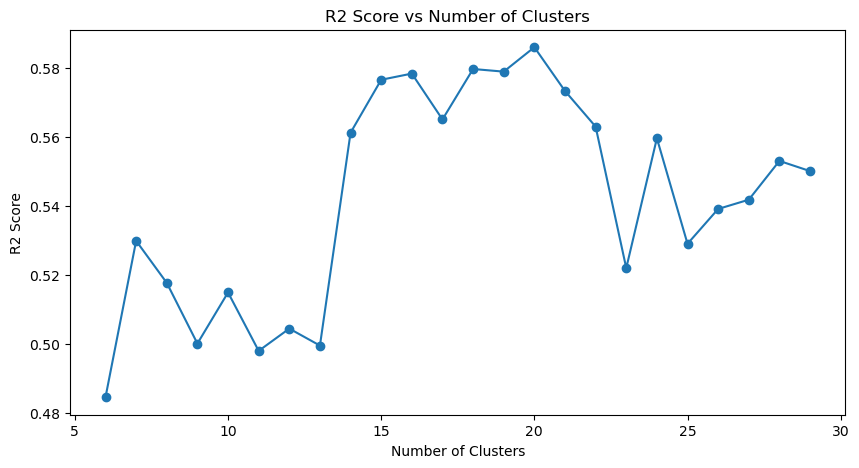

In [133]:
# plot r2s
plt.figure(figsize=(10, 5))
plt.plot(range(6, 30, 1), all_r2s, marker='o')
plt.title('R2 Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('R2 Score')

Text(0, 0.5, 'R2 Score')

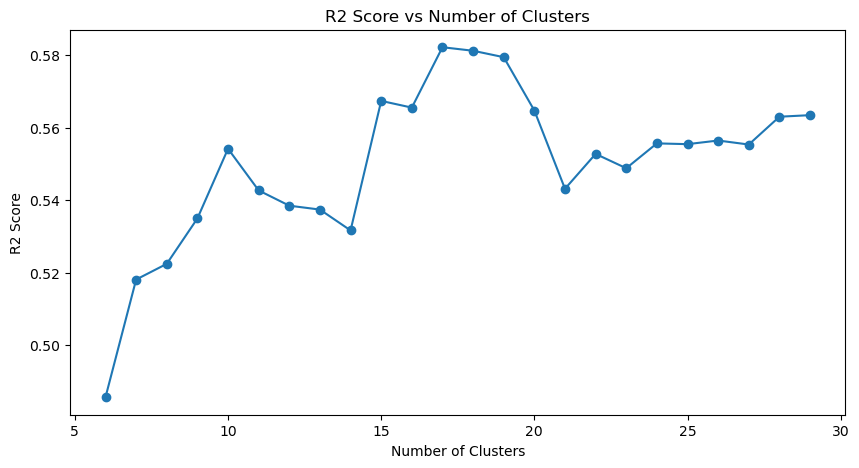

In [45]:
# plot r2s
plt.figure(figsize=(10, 5))
plt.plot(range(6, 30, 1), all_r2s, marker='o')
plt.title('R2 Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('R2 Score')

## Bow Features Alone


==================== N CLUSTER 6 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 20.92it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.5529 | MAE: 6.1688 | MAE STD: 4.3943 | R2: 0.3379 | Adj R2: 0.2460

Feature Weights:
     Feature  Average_Weight  Std_Weight
0       bias       51.361282    0.384718
1  SurgeMe_0        0.000000    0.000000
2  SurgeMe_1        0.239011    0.257755
3  SurgeMe_2       -6.445977    0.318173
4  SurgeMe_3        0.000000    0.000000
5  SurgeMe_4       -0.013014    0.120079
6  SurgeMe_5       -0.924583    0.185844
7     Case_1        0.000000    0.000000
8     Case_2        0.000000    0.000000
9     Case_3       -4.373601    0.480037

--- Per-Fold Performance Summary ---


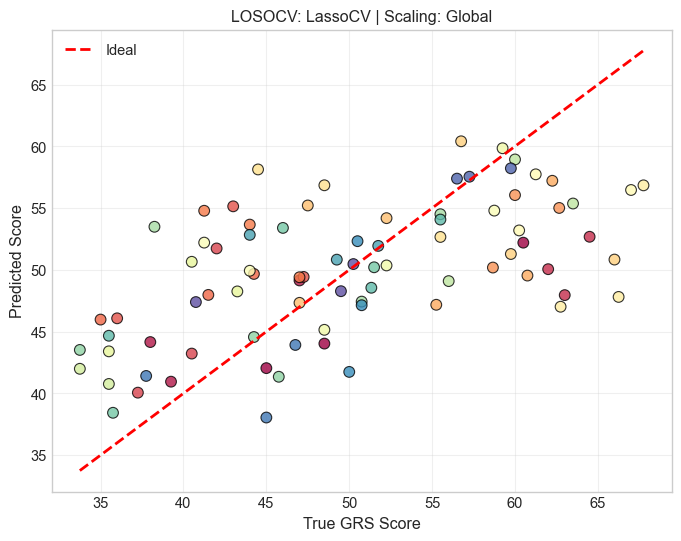

==================== N CLUSTER 7 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 30.35it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.5808 | MAE: 6.1314 | MAE STD: 4.2595 | R2: 0.3567 | Adj R2: 0.2570

Feature Weights:
      Feature  Average_Weight  Std_Weight
0        bias       51.098620    0.368779
1   SurgeMe_0       -0.000679    0.003526
2   SurgeMe_1        0.000000    0.000000
3   SurgeMe_2        0.025319    0.095695
4   SurgeMe_3        0.025622    0.074480
5   SurgeMe_4       -1.345462    0.168959
6   SurgeMe_5       -6.067271    0.249228
7   SurgeMe_6        0.007499    0.038968
8      Case_1        0.000000    0.000000
9      Case_2        0.001289    0.006697
10     Case_3       -3.567936    0.552043

--- Per-Fold Performance Summary ---


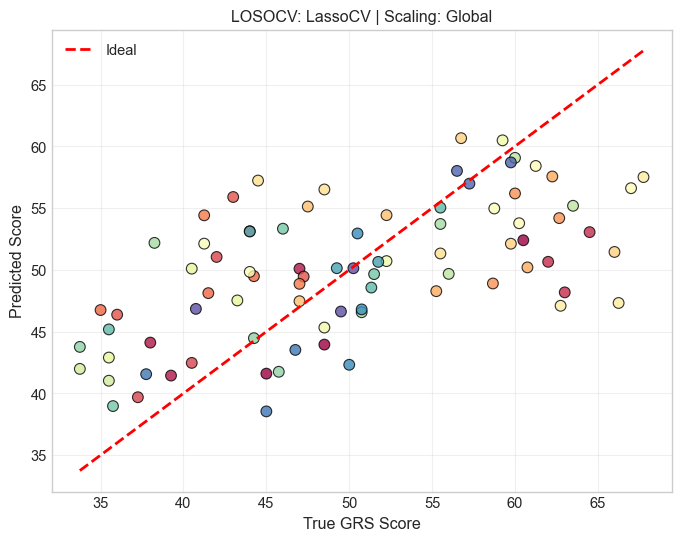

==================== N CLUSTER 8 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 29.79it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.5803 | MAE: 6.2064 | MAE STD: 4.3140 | R2: 0.3406 | Adj R2: 0.2276

Feature Weights:
      Feature  Average_Weight  Std_Weight
0        bias       51.034501    0.381838
1   SurgeMe_0       -4.753419    0.337820
2   SurgeMe_1       -0.025594    0.088099
3   SurgeMe_2        1.419849    0.585027
4   SurgeMe_3       -5.422994    0.509063
5   SurgeMe_4        0.833859    0.407944
6   SurgeMe_5        0.000000    0.000000
7   SurgeMe_6       -0.037998    0.197444
8   SurgeMe_7        0.041376    0.214996
9      Case_1        0.000000    0.000000
10     Case_2        0.529612    0.403123
11     Case_3       -3.918449    0.776324

--- Per-Fold Performance Summary ---


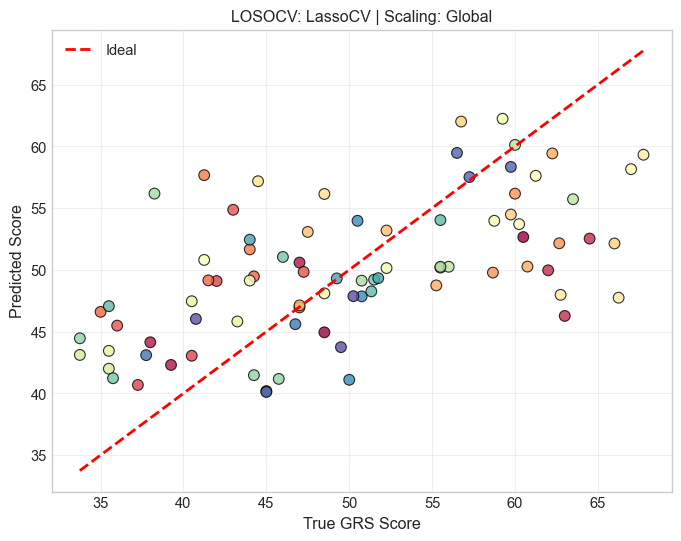

==================== N CLUSTER 9 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 24.84it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.5873 | MAE: 6.1579 | MAE STD: 4.3467 | R2: 0.3443 | Adj R2: 0.2207

Feature Weights:
      Feature  Average_Weight  Std_Weight
0        bias       51.243697    0.400977
1   SurgeMe_0       -5.045143    0.357004
2   SurgeMe_1       -0.008950    0.032271
3   SurgeMe_2       -4.912362    0.334850
4   SurgeMe_3        1.367278    0.406220
5   SurgeMe_4       -0.120831    0.184632
6   SurgeMe_5        0.000000    0.000000
7   SurgeMe_6        0.000000    0.000000
8   SurgeMe_7        2.009816    0.620659
9   SurgeMe_8        0.000000    0.000000
10     Case_1        0.000000    0.000000
11     Case_2        0.636423    0.355981
12     Case_3       -4.672106    0.670433

--- Per-Fold Performance Summary ---


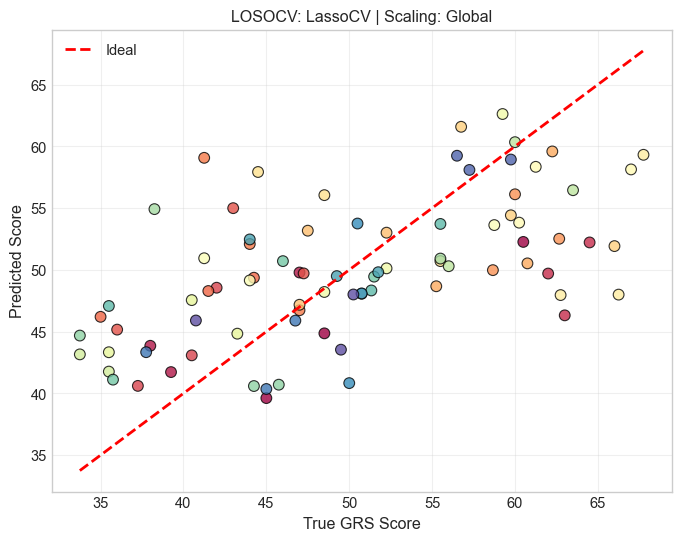

==================== N CLUSTER 10 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 27.07it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.5411 | MAE: 6.5017 | MAE STD: 4.2169 | R2: 0.3069 | Adj R2: 0.1641

Feature Weights:
      Feature  Average_Weight  Std_Weight
0        bias       50.571767    0.523885
1   SurgeMe_0        1.656374    0.413247
2   SurgeMe_1        0.305317    0.504939
3   SurgeMe_2        0.271736    0.224823
4   SurgeMe_3       -0.080889    0.208729
5   SurgeMe_4       -0.002442    0.012687
6   SurgeMe_5       -4.436193    0.479219
7   SurgeMe_6       -4.402531    0.381838
8   SurgeMe_7        0.000000    0.000000
9   SurgeMe_8        0.000000    0.000000
10  SurgeMe_9        0.000000    0.000000
11     Case_1        0.000000    0.000000
12     Case_2        0.083954    0.198004
13     Case_3       -2.032727    1.228095

--- Per-Fold Performance Summary ---


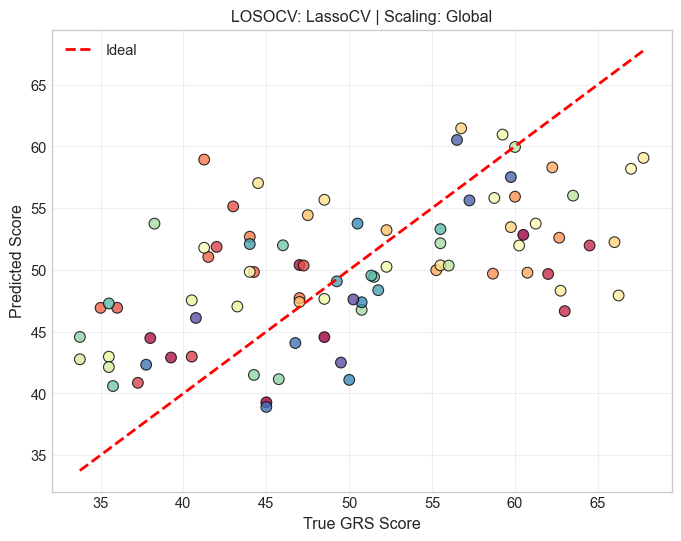

==================== N CLUSTER 11 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 27.63it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.5149 | MAE: 6.5048 | MAE STD: 4.1972 | R2: 0.3083 | Adj R2: 0.1534

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.992783    0.386016
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2       -0.051597    0.268108
4    SurgeMe_3        0.023671    0.068410
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5       -2.834181    0.593903
7    SurgeMe_6       -0.013317    0.053953
8    SurgeMe_7        0.052672    0.255049
9    SurgeMe_8        0.110547    0.512391
10   SurgeMe_9       -3.206483    0.438637
11  SurgeMe_10        1.759951    0.381800
12      Case_1        0.000000    0.000000
13      Case_2        0.047405    0.246324
14      Case_3       -0.215987    0.938575

--- Per-Fold Performance Summary ---


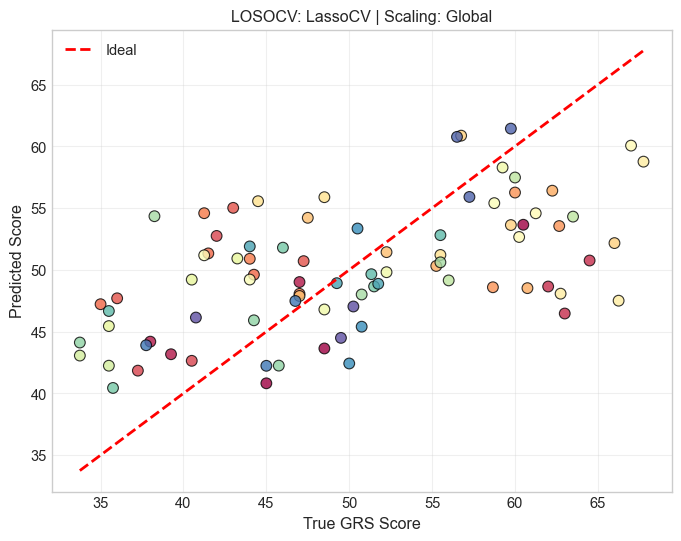

==================== N CLUSTER 12 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 24.49it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4887 | MAE: 6.5921 | MAE STD: 4.3217 | R2: 0.2829 | Adj R2: 0.1090

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.974287    0.362755
1    SurgeMe_0        2.406772    0.390453
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4        0.077793    0.404226
6    SurgeMe_5       -0.054606    0.283740
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7       -0.869358    0.494202
9    SurgeMe_8       -3.232987    0.625745
10   SurgeMe_9       -1.544852    0.400005
11  SurgeMe_10        1.858943    0.783963
12  SurgeMe_11        0.000000    0.000000
13      Case_1        0.000000    0.000000
14      Case_2        0.068845    0.345485
15      Case_3       -0.181343    0.936425

--- Per-Fold Performance Summary ---


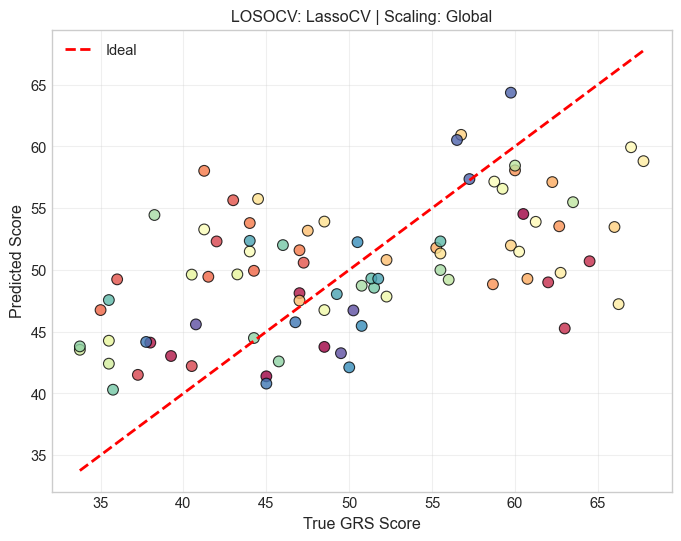

==================== N CLUSTER 13 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 25.52it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4758 | MAE: 6.7455 | MAE STD: 4.4579 | R2: 0.2454 | Adj R2: 0.0481

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.007294    0.421282
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1       -3.065206    1.098949
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3       -0.251016    0.366386
5    SurgeMe_4        0.008080    0.023655
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6       -1.210576    0.441524
8    SurgeMe_7       -0.138669    0.720545
9    SurgeMe_8        0.021736    0.112943
10   SurgeMe_9       -0.493948    0.604789
11  SurgeMe_10        0.000000    0.000000
12  SurgeMe_11        3.687671    0.505511
13  SurgeMe_12        2.238987    0.972922
14      Case_1        0.000000    0.000000
15      Case_2        0.062946    0.327075
16      Case_3       -0.276774    1.140887

--- Per-Fold Performance Summary ---


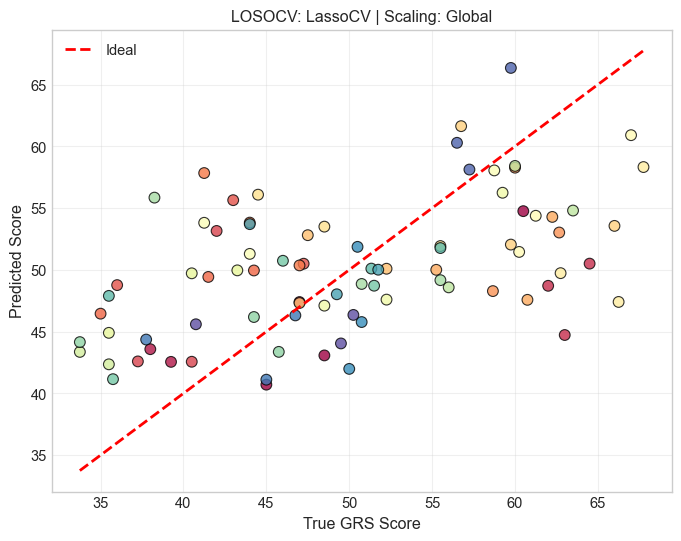

==================== N CLUSTER 14 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 24.35it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4488 | MAE: 6.8293 | MAE STD: 4.4137 | R2: 0.2368 | Adj R2: 0.0222

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.012183    0.433348
1    SurgeMe_0       -0.007095    0.036866
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3       -0.167393    0.828514
5    SurgeMe_4        0.054392    0.208258
6    SurgeMe_5        4.584850    0.281478
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7        0.000000    0.000000
9    SurgeMe_8       -0.243004    0.720920
10   SurgeMe_9       -0.136619    0.613470
11  SurgeMe_10        0.000000    0.000000
12  SurgeMe_11       -0.135849    0.426369
13  SurgeMe_12        0.240995    0.943125
14  SurgeMe_13       -0.324535    1.179451
15      Case_1        0.000000    0.000000
16      Case_2        0.043244    0.224705
17      Case_3       -0.271359    1.076585

--- Per-Fold Performance Summary ---


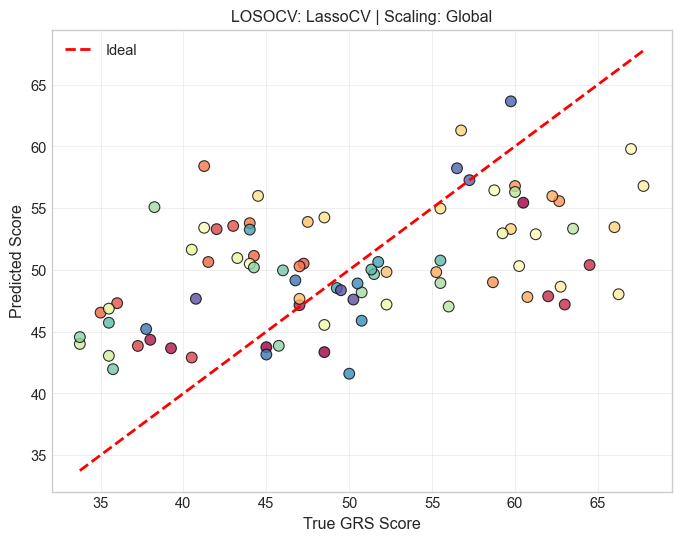

==================== N CLUSTER 15 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 26.04it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4523 | MAE: 6.8246 | MAE STD: 4.4142 | R2: 0.2375 | Adj R2: 0.0076

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.020115    0.451787
1    SurgeMe_0        0.325106    0.967801
2    SurgeMe_1       -0.009363    0.048653
3    SurgeMe_2       -0.382259    1.171350
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4       -0.175606    0.523849
6    SurgeMe_5        4.524178    0.563092
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7       -0.009078    0.047172
9    SurgeMe_8       -0.227374    0.545950
10   SurgeMe_9        0.084271    0.358289
11  SurgeMe_10        0.000000    0.000000
12  SurgeMe_11        0.000000    0.000000
13  SurgeMe_12       -0.033356    0.173323
14  SurgeMe_13        0.356473    1.287693
15  SurgeMe_14        0.000000    0.000000
16      Case_1        0.000000    0.000000
17      Case_2        0.040198    0.208877
18      Case_3       -0.292602    1.124765

--- Per-

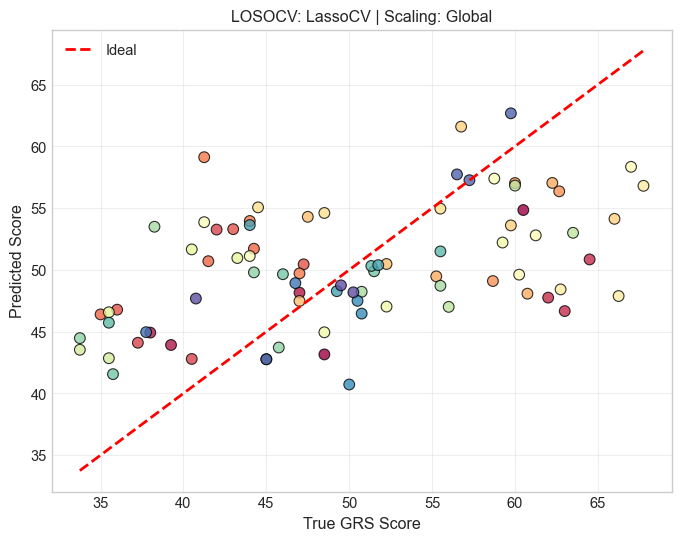

==================== N CLUSTER 16 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 22.35it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4538 | MAE: 6.8307 | MAE STD: 4.3793 | R2: 0.2401 | Adj R2: -0.0050

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.023437    0.461707
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.305720    1.102323
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3       -0.192658    0.464676
5    SurgeMe_4        0.051562    0.243927
6    SurgeMe_5        0.065527    0.340490
7    SurgeMe_6        4.507701    0.322481
8    SurgeMe_7        0.000000    0.000000
9    SurgeMe_8        0.000000    0.000000
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10       -0.766899    1.327138
12  SurgeMe_11       -0.023862    0.123992
13  SurgeMe_12       -0.016207    0.060425
14  SurgeMe_13        0.050557    0.262701
15  SurgeMe_14       -0.144987    0.539786
16  SurgeMe_15       -0.928931    0.645993
17      Case_1        0.000000    0.000000
18      Case_2        0.049165    0.255468
19      

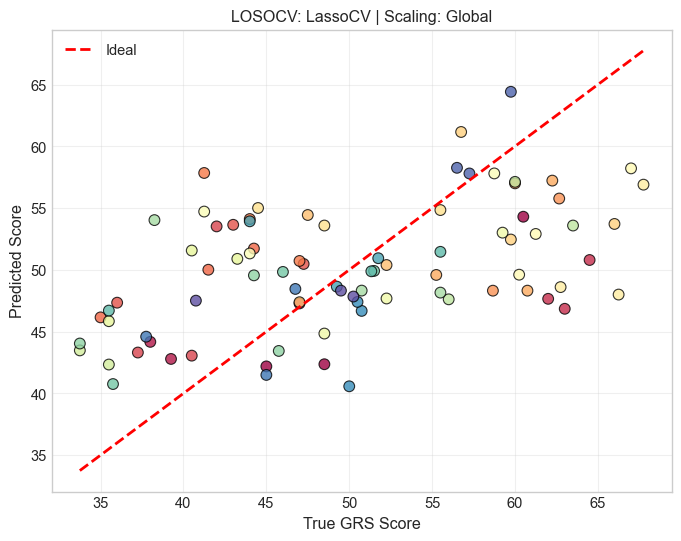

==================== N CLUSTER 17 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 26.86it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4705 | MAE: 6.7804 | MAE STD: 4.2429 | R2: 0.2616 | Adj R2: 0.0074

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.969863    0.363110
1    SurgeMe_0       -0.046507    0.241660
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2       -0.009873    0.051304
4    SurgeMe_3       -0.010275    0.041182
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6       -0.967551    0.496986
8    SurgeMe_7        0.003934    0.020444
9    SurgeMe_8        0.000000    0.000000
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10        0.155452    0.807751
12  SurgeMe_11       -0.422235    0.412488
13  SurgeMe_12        0.000000    0.000000
14  SurgeMe_13        0.000000    0.000000
15  SurgeMe_14        0.000000    0.000000
16  SurgeMe_15       -0.658354    0.885087
17  SurgeMe_16        4.501100    0.358346
18      Case_1        0.000000    0.000000
19      C

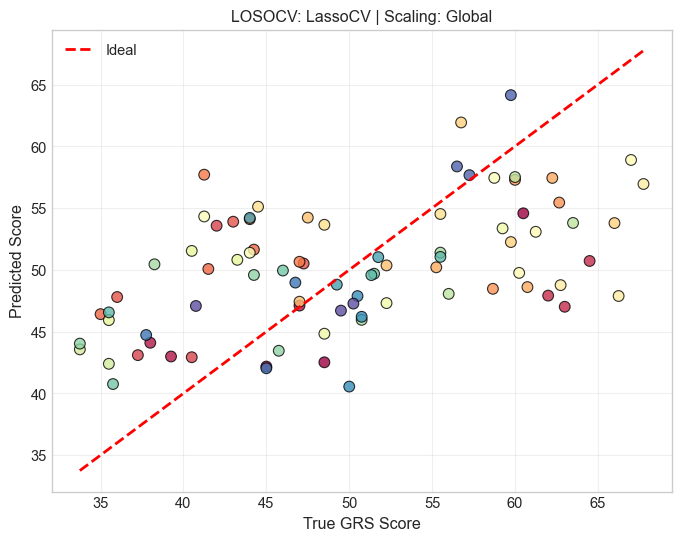

==================== N CLUSTER 18 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 26.80it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4147 | MAE: 7.1352 | MAE STD: 4.4813 | R2: 0.1806 | Adj R2: -0.1199

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.102161    0.550217
1    SurgeMe_0       -0.298200    0.308273
2    SurgeMe_1        2.737489    0.700771
3    SurgeMe_2       -1.486306    1.812390
4    SurgeMe_3       -0.984005    0.596102
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5        0.616468    1.232594
7    SurgeMe_6       -2.316155    0.781433
8    SurgeMe_7       -0.163387    0.310006
9    SurgeMe_8       -0.383805    0.853389
10   SurgeMe_9        0.034055    0.123109
11  SurgeMe_10        0.425431    0.499455
12  SurgeMe_11       -0.746925    0.606970
13  SurgeMe_12        0.000000    0.000000
14  SurgeMe_13        0.000000    0.000000
15  SurgeMe_14       -0.150224    0.506588
16  SurgeMe_15        0.070254    0.211999
17  SurgeMe_16        0.297177    0.466249
18  SurgeMe_17        0.205535    0.655738
19      

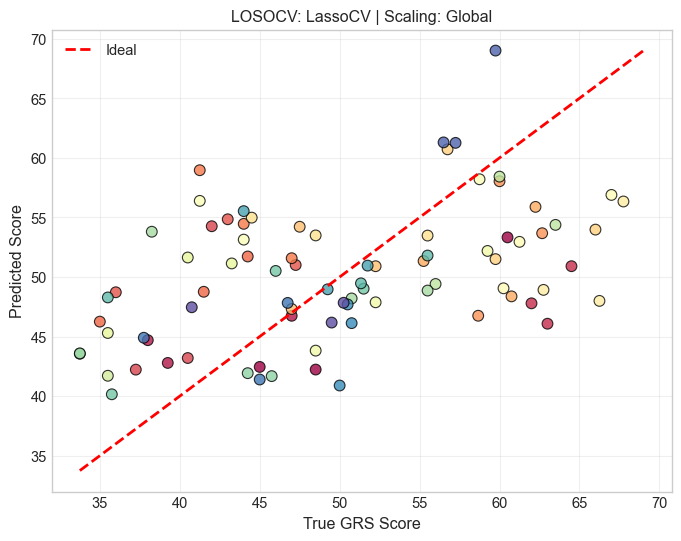

==================== N CLUSTER 19 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 25.40it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4048 | MAE: 7.2066 | MAE STD: 4.5126 | R2: 0.1655 | Adj R2: -0.1598

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.233493    0.671715
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2        3.052772    0.810525
4    SurgeMe_3        0.141956    0.369478
5    SurgeMe_4        0.104902    0.286674
6    SurgeMe_5       -0.492255    0.932727
7    SurgeMe_6       -0.557604    0.416026
8    SurgeMe_7        0.052285    0.192269
9    SurgeMe_8        0.983548    1.605239
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10        0.000000    0.000000
12  SurgeMe_11        0.372910    0.822242
13  SurgeMe_12       -0.207602    0.378137
14  SurgeMe_13        0.387299    0.481446
15  SurgeMe_14       -1.662508    2.170506
16  SurgeMe_15       -0.280426    0.641337
17  SurgeMe_16       -0.849331    0.702830
18  SurgeMe_17       -0.766114    0.571929
19  Surg

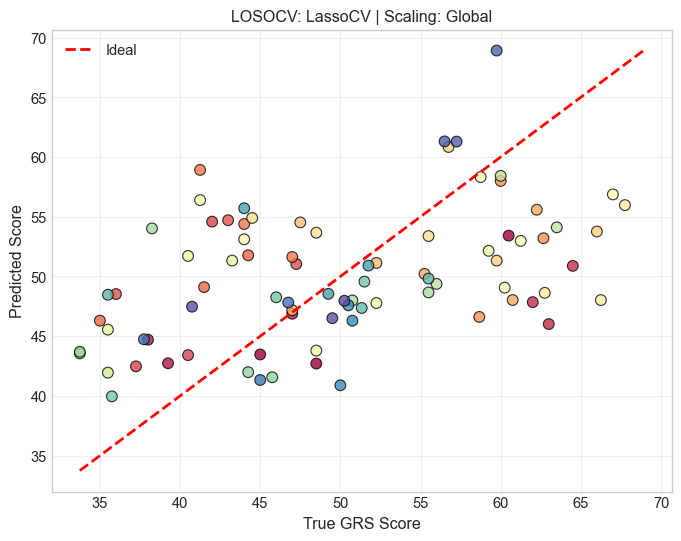

==================== N CLUSTER 20 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 26.33it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.3890 | MAE: 7.2943 | MAE STD: 4.7548 | R2: 0.1249 | Adj R2: -0.2372

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.514630    0.723936
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2        2.773934    0.853638
4    SurgeMe_3       -0.430411    0.491718
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5       -0.602421    0.796087
7    SurgeMe_6       -0.137203    0.419188
8    SurgeMe_7       -3.286516    2.257811
9    SurgeMe_8       -0.644921    0.905678
10   SurgeMe_9        0.034224    0.128058
11  SurgeMe_10        2.506997    1.707481
12  SurgeMe_11        0.000000    0.000000
13  SurgeMe_12        0.030041    0.156097
14  SurgeMe_13       -0.403779    0.976611
15  SurgeMe_14        1.330749    0.763975
16  SurgeMe_15        0.000000    0.000000
17  SurgeMe_16       -1.362328    0.945540
18  SurgeMe_17        0.000000    0.000000
19  Surg

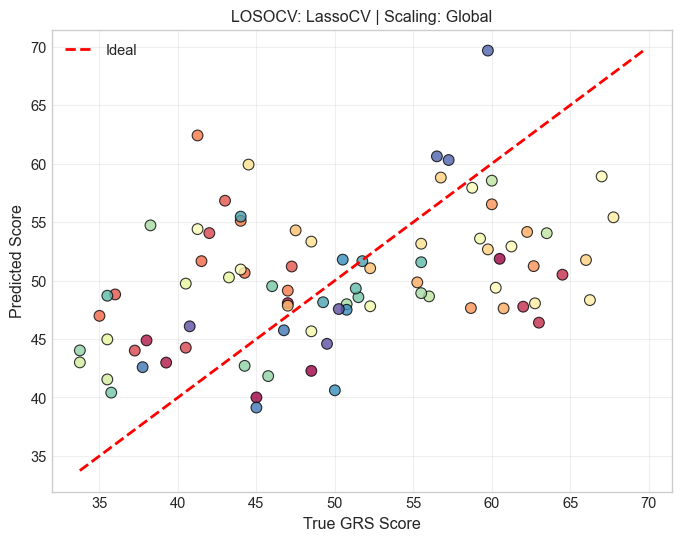

==================== N CLUSTER 21 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 26.32it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4827 | MAE: 6.7371 | MAE STD: 4.2975 | R2: 0.2630 | Adj R2: -0.0603

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.952553    0.321085
1    SurgeMe_0       -0.159089    0.760800
2    SurgeMe_1        0.160310    0.812530
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5        0.000381    0.001980
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7        0.000000    0.000000
9    SurgeMe_8       -0.009153    0.047559
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10        0.000000    0.000000
12  SurgeMe_11        4.618427    0.422916
13  SurgeMe_12        0.000000    0.000000
14  SurgeMe_13        0.000000    0.000000
15  SurgeMe_14       -0.233144    0.670769
16  SurgeMe_15        0.000000    0.000000
17  SurgeMe_16       -0.066962    0.347944
18  SurgeMe_17       -0.028407    0.113854
19  Surg

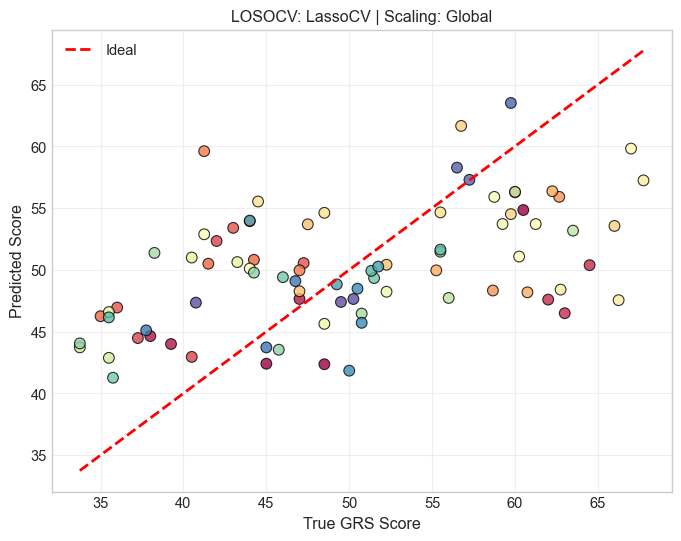

==================== N CLUSTER 22 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 25.25it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4599 | MAE: 6.8313 | MAE STD: 4.4626 | R2: 0.2315 | Adj R2: -0.1253

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.967028    0.355008
1    SurgeMe_0        4.542201    0.747074
2    SurgeMe_1       -0.025872    0.134434
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4       -0.052480    0.223889
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7        0.000000    0.000000
9    SurgeMe_8        0.000000    0.000000
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10        0.000000    0.000000
12  SurgeMe_11        0.000000    0.000000
13  SurgeMe_12        0.075378    0.391675
14  SurgeMe_13        0.264954    1.376742
15  SurgeMe_14        0.009764    0.050736
16  SurgeMe_15       -0.007417    0.038539
17  SurgeMe_16       -0.086675    0.450379
18  SurgeMe_17       -0.172229    0.800367
19  Surg

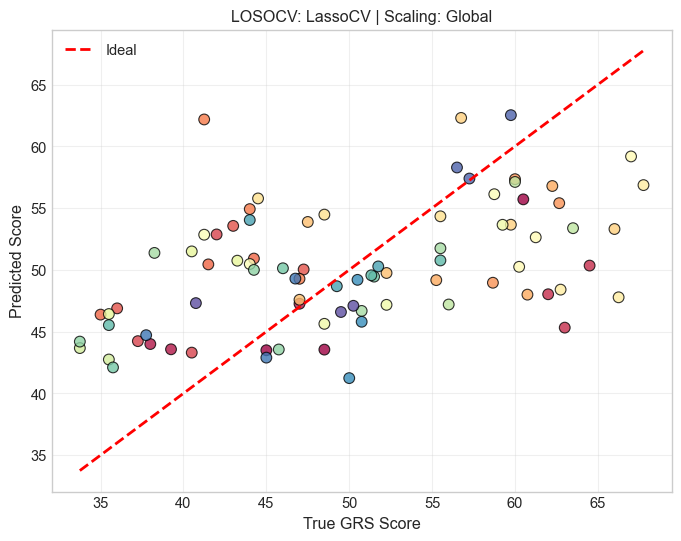

==================== N CLUSTER 23 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 25.53it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4214 | MAE: 6.8843 | MAE STD: 4.4924 | R2: 0.2200 | Adj R2: -0.1628

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.001015    0.403336
1    SurgeMe_0        0.580556    1.069031
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2       -0.662241    1.000672
4    SurgeMe_3       -0.233963    0.382165
5    SurgeMe_4        0.079636    0.413798
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7        0.004675    0.024292
9    SurgeMe_8        0.000000    0.000000
10   SurgeMe_9       -0.789474    1.136009
11  SurgeMe_10        0.000000    0.000000
12  SurgeMe_11        0.000000    0.000000
13  SurgeMe_12        0.000000    0.000000
14  SurgeMe_13       -0.035924    0.186667
15  SurgeMe_14        0.192693    0.496297
16  SurgeMe_15        0.000000    0.000000
17  SurgeMe_16       -0.027040    0.098125
18  SurgeMe_17       -0.596187    0.914655
19  Surg

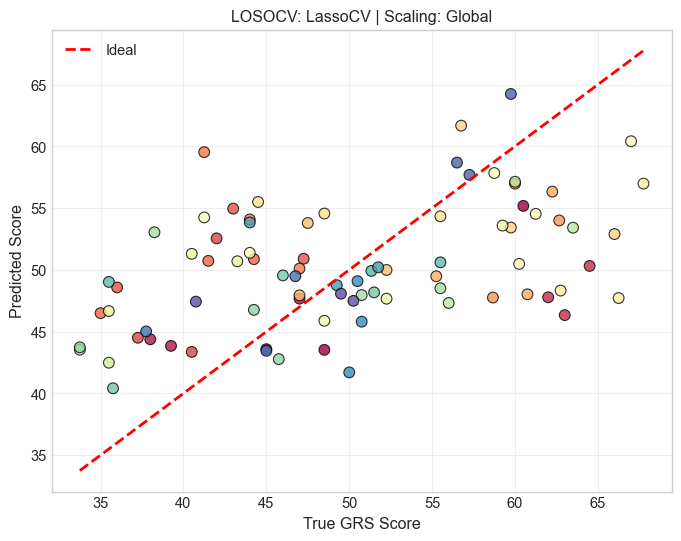

==================== N CLUSTER 24 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 20.69it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4205 | MAE: 7.0081 | MAE STD: 4.4797 | R2: 0.2015 | Adj R2: -0.2125

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.100166    0.512675
1    SurgeMe_0        3.984191    0.552665
2    SurgeMe_1       -0.887547    0.348429
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3        0.191849    0.431860
5    SurgeMe_4       -0.075205    0.233863
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7        0.000000    0.000000
9    SurgeMe_8       -0.113980    0.192725
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10       -0.043147    0.224200
12  SurgeMe_11        0.029808    0.154888
13  SurgeMe_12        0.000000    0.000000
14  SurgeMe_13        0.010850    0.056379
15  SurgeMe_14       -0.186952    0.406557
16  SurgeMe_15       -0.494804    0.904542
17  SurgeMe_16       -0.147333    0.341232
18  SurgeMe_17       -0.676482    1.479296
19  Surg

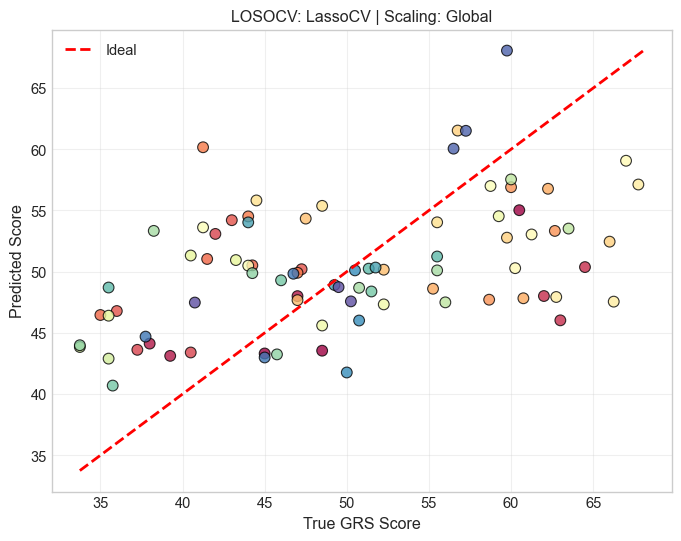

==================== N CLUSTER 25 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 18.65it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4617 | MAE: 6.7848 | MAE STD: 4.3907 | R2: 0.2462 | Adj R2: -0.1663

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       49.974402    0.387024
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2       -1.005898    0.581539
4    SurgeMe_3       -0.641107    0.752315
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7        4.692041    0.671480
9    SurgeMe_8        0.000000    0.000000
10   SurgeMe_9        0.295387    1.100019
11  SurgeMe_10       -0.016454    0.085497
12  SurgeMe_11        0.000000    0.000000
13  SurgeMe_12        0.000000    0.000000
14  SurgeMe_13        0.000000    0.000000
15  SurgeMe_14       -0.029900    0.108016
16  SurgeMe_15        0.000000    0.000000
17  SurgeMe_16        0.000000    0.000000
18  SurgeMe_17       -0.412657    0.292899
19  Surg

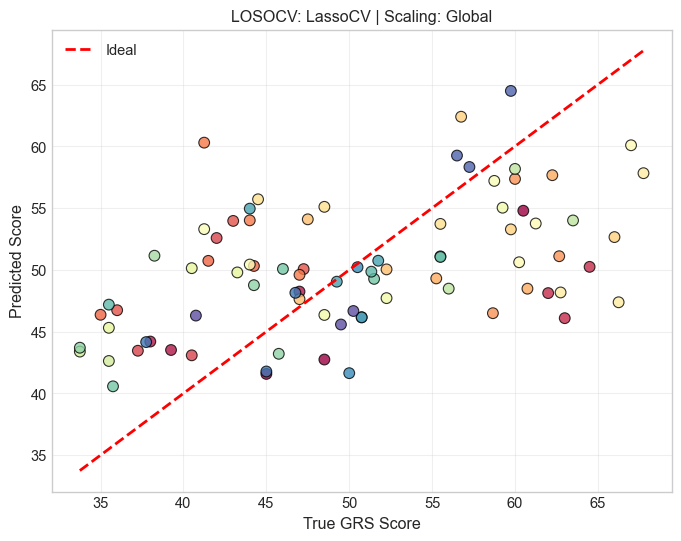

==================== N CLUSTER 26 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 16.44it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4823 | MAE: 6.6923 | MAE STD: 4.4919 | R2: 0.2502 | Adj R2: -0.1824

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.024862    0.461657
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4        0.028022    0.133101
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7       -0.066638    0.240498
9    SurgeMe_8        0.000000    0.000000
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10       -0.088406    0.196100
12  SurgeMe_11        0.448769    1.643246
13  SurgeMe_12        0.000000    0.000000
14  SurgeMe_13        0.000000    0.000000
15  SurgeMe_14       -1.176488    0.834473
16  SurgeMe_15        4.985981    0.899099
17  SurgeMe_16       -0.569027    1.033526
18  SurgeMe_17        0.078180    0.303309
19  Surg

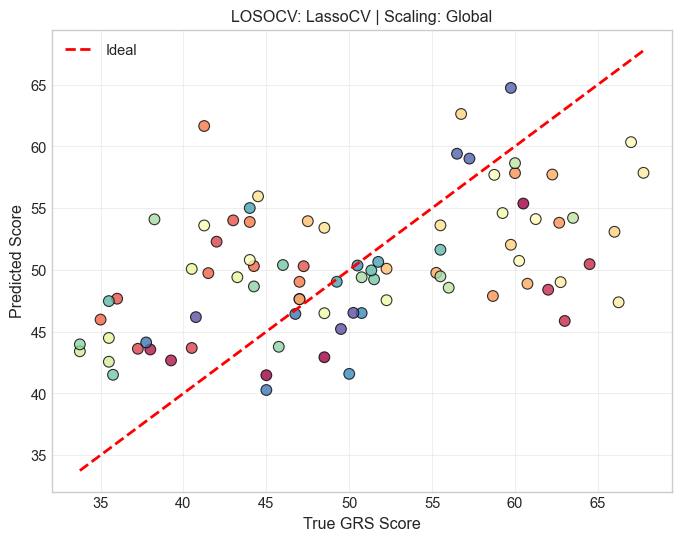

==================== N CLUSTER 27 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 24.19it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4627 | MAE: 6.9348 | MAE STD: 4.5819 | R2: 0.2026 | Adj R2: -0.2821

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.097802    0.566581
1    SurgeMe_0       -0.418493    0.786551
2    SurgeMe_1        0.138898    0.455174
3    SurgeMe_2        0.000000    0.000000
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5       -0.806209    0.516261
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7        0.000000    0.000000
9    SurgeMe_8       -0.030632    0.159170
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10        0.109396    0.405668
12  SurgeMe_11       -0.103290    0.328261
13  SurgeMe_12        4.587820    0.783980
14  SurgeMe_13        0.000000    0.000000
15  SurgeMe_14        0.290238    1.069026
16  SurgeMe_15       -0.027423    0.107477
17  SurgeMe_16        0.141174    0.733564
18  SurgeMe_17       -0.091756    0.271642
19  Surg

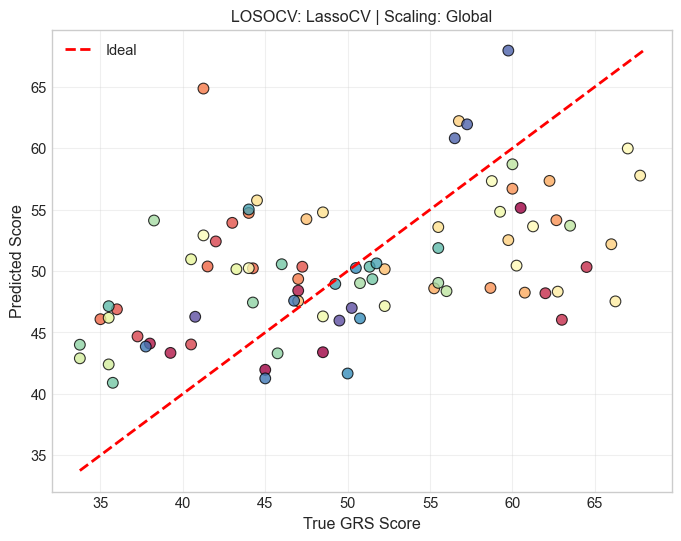

==================== N CLUSTER 28 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 22.81it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4659 | MAE: 6.8802 | MAE STD: 4.4931 | R2: 0.2206 | Adj R2: -0.2782

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.089032    0.537587
1    SurgeMe_0        0.000000    0.000000
2    SurgeMe_1        0.197543    0.780668
3    SurgeMe_2       -0.935517    0.566727
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4        0.000000    0.000000
6    SurgeMe_5        0.000000    0.000000
7    SurgeMe_6        0.000000    0.000000
8    SurgeMe_7       -0.044805    0.217779
9    SurgeMe_8        0.000000    0.000000
10   SurgeMe_9       -0.024780    0.128761
11  SurgeMe_10       -0.105293    0.313892
12  SurgeMe_11        0.000000    0.000000
13  SurgeMe_12        0.001686    0.008761
14  SurgeMe_13        0.133904    0.399946
15  SurgeMe_14        0.000000    0.000000
16  SurgeMe_15        0.090525    0.330934
17  SurgeMe_16       -0.545702    1.444549
18  SurgeMe_17        0.000000    0.000000
19  Surg

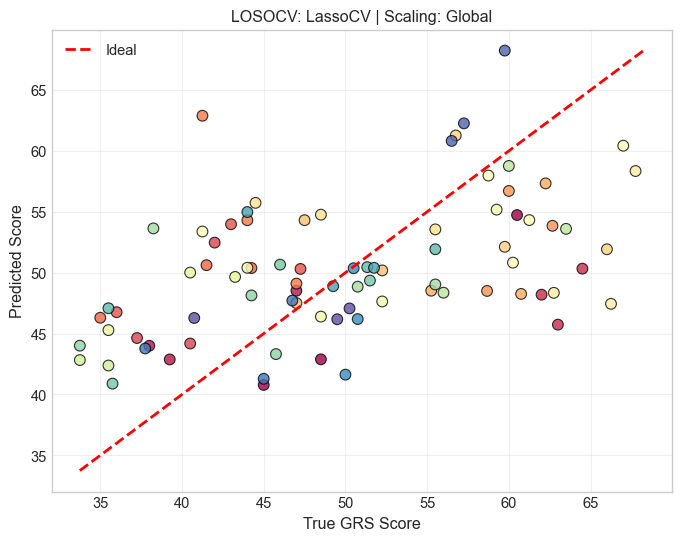

==================== N CLUSTER 29 ===================


LOSOCV Folds: 100%|██████████| 28/28 [00:01<00:00, 19.98it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.4449 | MAE: 6.9603 | MAE STD: 4.6097 | R2: 0.1956 | Adj R2: -0.3462

Feature Weights:
       Feature  Average_Weight  Std_Weight
0         bias       50.096505    0.510239
1    SurgeMe_0        0.509967    0.545867
2    SurgeMe_1        0.000000    0.000000
3    SurgeMe_2        0.006670    0.034656
4    SurgeMe_3        0.000000    0.000000
5    SurgeMe_4        0.064158    0.191833
6    SurgeMe_5       -0.004048    0.021035
7    SurgeMe_6        0.571217    1.311360
8    SurgeMe_7       -0.200017    0.482846
9    SurgeMe_8        0.000000    0.000000
10   SurgeMe_9        0.000000    0.000000
11  SurgeMe_10        1.033539    2.203506
12  SurgeMe_11        0.000000    0.000000
13  SurgeMe_12        0.000000    0.000000
14  SurgeMe_13        0.000000    0.000000
15  SurgeMe_14        0.000000    0.000000
16  SurgeMe_15        0.000000    0.000000
17  SurgeMe_16       -0.319832    0.692245
18  SurgeMe_17        0.000000    0.000000
19  Surg

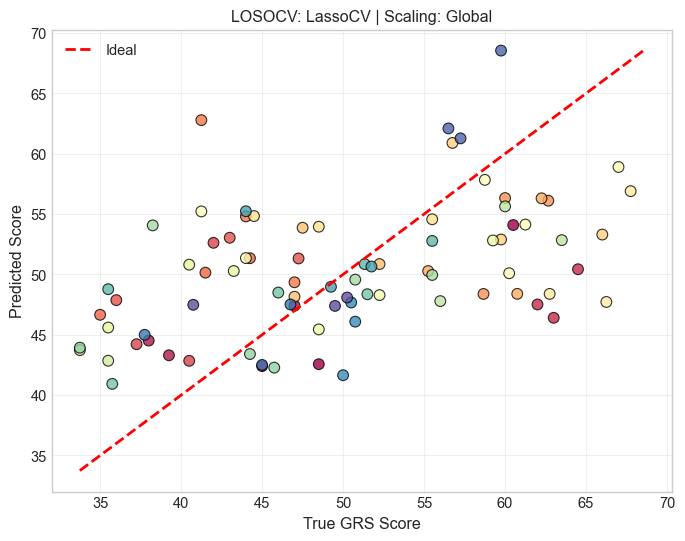

In [397]:
for n_cluster in range(6, 30, 1):
    print("==================== N CLUSTER", n_cluster, "===================")
    vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=42, model_type='kmeans', n_init=20,
                              feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                              power_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                              )

    vocab.fit(df_window)
    df_voc = vocab.transform(df_window)

    candidate_features = [col for col in df_voc.columns if col not in ['video_id']]
    comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)
    
    if not any('Case_1' in col for col in comb_df.columns):
        comb_df = pd.concat([comb_df, df_case_onehot], axis=1)
    candidate_features += ['Case_1', 'Case_2', 'Case_3']

    _, _, _ = evaluate_loso_model(comb_df, 
                                  [], 
                                  model_class=LassoCV, 
                                  model_params={'alphas': np.logspace(-1, 1, 20)}, 
                                  extra_features=candidate_features, 
                                  print_fold_metrics=False, 
                                  pca_components=None)

In [19]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from tqdm import tqdm


def run_hybrid_vocabulary_loso_old(
    df_videos,
    df_windows,
    primary_features,
    vocab,
    selector=None,
    model=RidgeCV(np.logspace(-1, 1, 10)),
    extra_features=None,
    target_col='score',
    surgeon_col='Participant Number',
    video_col='video_id',
):
    if extra_features is None: extra_features = []

    unique_surgeons = df_videos[surgeon_col].unique()
    all_preds, all_true, all_surgeons = [], [], []

    baseline_selection_history = []  # Track which baseline features are selected each fold
    nb_selected_per_fold = []
    fold_centroids = []  
    # Storage for the kinematic meaning of selected clusters
    selected_profiles = []
    
    for surgeon_out in tqdm(unique_surgeons, desc="Running LOSO"):
        # --- 1. Split Data ---
        train_vids_idx = df_videos[df_videos[surgeon_col] != surgeon_out].index
        test_vids_idx = df_videos[df_videos[surgeon_col] == surgeon_out].index
        
        df_tr_vid = df_videos.loc[train_vids_idx].copy()
        df_te_vid = df_videos.loc[test_vids_idx].copy()
        
        train_vids_list = df_tr_vid[video_col].unique()
        df_tr_win = df_windows[df_windows[video_col].isin(train_vids_list)]
        df_te_win = df_windows[df_windows[video_col].isin(df_te_vid[video_col])]

        # --- 2. Fit/Transform Vocabulary ---
        vocab.fit(df_tr_win)
        X_tr_bow_raw = vocab.transform(df_tr_win)
        X_te_bow_raw = vocab.transform(df_te_win)
        
        # --- 3. Scale BoW ---
        bow_scaler = StandardScaler()
        X_tr_bow = pd.DataFrame(bow_scaler.fit_transform(X_tr_bow_raw), 
                                columns=X_tr_bow_raw.columns, index=X_tr_bow_raw.index)
        X_te_bow = pd.DataFrame(bow_scaler.transform(X_te_bow_raw), 
                                columns=X_te_bow_raw.columns, index=X_te_bow_raw.index)

        # --- 4. Scale and Baseline (PC1 + Extras) ---
        kinematic_scaler = StandardScaler()
        df_tr_vid[primary_features] = kinematic_scaler.fit_transform(df_tr_vid[primary_features])
        df_te_vid[primary_features] = kinematic_scaler.transform(df_te_vid[primary_features])
        
        pca = PCA(n_components=1)
        pc1_tr = pca.fit_transform(df_tr_vid[primary_features])
        pc1_te = pca.transform(df_te_vid[primary_features])
        # scale pc1
        pc1_scaler = StandardScaler()
        pc1_tr = pc1_scaler.fit_transform(pc1_tr)
        pc1_te = pc1_scaler.transform(pc1_te)

        X_tr_base = np.hstack([pc1_tr, df_tr_vid[extra_features].values])
        X_te_base = np.hstack([pc1_te, df_te_vid[extra_features].values])

        # --- 5. Partial R2 Selection ---
        y_tr = df_tr_vid.set_index(video_col).loc[X_tr_bow.index, target_col].values
        if selector == None:
            selected_bow = [bow for bow in X_tr_bow.columns]
        else:
            selected_bow, selected_pr2s = selector.select_features(X_tr_base, y_tr, X_tr_bow)
            nb_selected_per_fold.append(len(selected_bow))
        
        
        # --- NEW: TRACK CENTROIDS OF SELECTED FEATURES ---
        # Get the cluster centers (centroids) from the fitted KMeans/GMM
        # Shape: (n_clusters, n_kinematic_features)
        centers = vocab.model.cluster_centers_ if vocab.model_type == 'kmeans' else vocab.model.means_

        fold_centroids.append(centers)

        
        if selector != None:
            for feat_name, pr2 in zip(selected_bow, selected_pr2s):
                # Extract the cluster index from the string 'SurgeMe_X'
                cluster_idx = int(feat_name.split('_')[1])
                centroid_coords = centers[cluster_idx]
                # Store the behavioral profile of this selected feature
                profile = {
                    'Surgeon_Out': surgeon_out,
                    'Feature_Name': feat_name,
                    'PR2': pr2
                }
                # Map kinematic feature names to their centroid values
                for i, col in enumerate(vocab.feature_cols):
                    profile[col] = centroid_coords[i]
                
                selected_profiles.append(profile)


        # --- 6. Final Assembly & Prediction ---
        X_train_final = np.hstack([X_tr_base, X_tr_bow[selected_bow].values])
        X_test_final = np.hstack([X_te_base, X_te_bow[selected_bow].values])
        y_test = df_te_vid.set_index(video_col).loc[X_te_bow.index, target_col].values

        model.fit(X_train_final, y_tr)

        if selector is None:
            # Determine how many features were passed in X_tr_base
            num_base_feats = X_tr_base.shape[1]
            base_feature_names = ['PC1'] + extra_features
            
            # Check selection using coefficient magnitude (e.g., > 0.05)
            # Note: model.coef_ will have shape (num_base_feats + len(selected_bow),)
            selected_indices = np.where(np.abs(model.coef_) > 0.05)[0]
            
            # Track which baseline features survived the threshold
            fold_baseline_selection = {
                name: (1 if i in selected_indices else 0) 
                for i, name in enumerate(base_feature_names)
            }
            baseline_selection_history.append(fold_baseline_selection)

            bow_selected_count = sum(1 for i in selected_indices if i >= num_base_feats)
            nb_selected_per_fold.append(bow_selected_count)

        preds = model.predict(X_test_final)

        all_preds.extend(preds)
        all_true.extend(y_test)
        all_surgeons.extend([surgeon_out] * len(y_test))

    # --- 7. Final Reporting ---
    results_df = pd.DataFrame({'Surgeon': all_surgeons, 'True': all_true, 'Pred': all_preds})
    profile_df = pd.DataFrame(selected_profiles) # This contains your behavioral data
    baseline_stats = pd.DataFrame(baseline_selection_history).mean()
    
    _print_summary(all_true, all_preds, nb_selected_per_fold)
    
    print("\n=== Baseline Feature Selection Consistency ===")
    for feat, fraction in baseline_stats.items():
        print(f"{feat}: Selected in {fraction*100:.1f}% of folds")
    
    return results_df, profile_df, fold_centroids

def _print_summary(y_true, y_pred, nb_selected):
    print(f"\n=== Hybrid SurgeMe LOSO Summary ===")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f} ± {np.std(np.abs(np.array(y_true)-np.array(y_pred))):.4f}")
    print(f"Spearman R: {spearmanr(y_true, y_pred)[0]:.4f}")
    print(f"Overall R2: {r2_score(y_true, y_pred):.4f}")
    print(f"Number of selected features: {np.mean(nb_selected):.2f} ± {np.std(nb_selected):.2f}")


def run_hybrid_vocabulary_loso(
    df_videos,
    df_windows,
    primary_features,
    vocab,
    selector=None,
    model=RidgeCV(np.logspace(-1, 1, 10)),
    extra_features=None,
    target_col='score',
    surgeon_col='Participant Number',
    video_col='video_id',
    use_baseline=True  # NEW: Flag to toggle PC1/Extra features
):
    if extra_features is None: extra_features = []

    unique_surgeons = df_videos[surgeon_col].unique()
    all_preds, all_true, all_surgeons = [], [], []
    baseline_selection_history = []
    nb_selected_per_fold = []
    fold_centroids = []  
    selected_profiles = []
    
    for surgeon_out in tqdm(unique_surgeons, desc="Running LOSO"):
        # --- 1. Split Data ---
        train_vids_idx = df_videos[df_videos[surgeon_col] != surgeon_out].index
        test_vids_idx = df_videos[df_videos[surgeon_col] == surgeon_out].index
        
        df_tr_vid = df_videos.loc[train_vids_idx].copy()
        df_te_vid = df_videos.loc[test_vids_idx].copy()
        
        df_tr_win = df_windows[df_windows[video_col].isin(df_tr_vid[video_col])]
        df_te_win = df_windows[df_windows[video_col].isin(df_te_vid[video_col])]

        # --- 2. Vocabulary & BoW Scaling ---
        vocab.fit(df_tr_win)
        X_tr_bow_raw = vocab.transform(df_tr_win)
        X_te_bow_raw = vocab.transform(df_te_win)
        
        bow_scaler = StandardScaler()
        X_tr_bow = pd.DataFrame(bow_scaler.fit_transform(X_tr_bow_raw), 
                                columns=X_tr_bow_raw.columns, index=X_tr_bow_raw.index)
        X_te_bow = pd.DataFrame(bow_scaler.transform(X_te_bow_raw), 
                                columns=X_te_bow_raw.columns, index=X_te_bow_raw.index)

        # --- 3. Conditional Baseline Processing ---
        if use_baseline:
            kinematic_scaler = StandardScaler()
            df_tr_vid[primary_features] = kinematic_scaler.fit_transform(df_tr_vid[primary_features])
            df_te_vid[primary_features] = kinematic_scaler.transform(df_te_vid[primary_features])
            
            pca = PCA(n_components=1)
            pc1_tr = StandardScaler().fit_transform(pca.fit_transform(df_tr_vid[primary_features]))
            pc1_te = StandardScaler().fit(pca.transform(df_tr_vid[primary_features])).transform(pca.transform(df_te_vid[primary_features]))

            X_tr_base = np.hstack([pc1_tr, df_tr_vid[extra_features].values])
            X_te_base = np.hstack([pc1_te, df_te_vid[extra_features].values])
        else:
            # Create an empty array if baseline is not used
            X_tr_base = np.empty((len(df_tr_vid), 0))
            X_te_base = np.empty((len(df_te_vid), 0))

        y_tr = df_tr_vid.set_index(video_col).loc[X_tr_bow.index, target_col].values

        # --- 4. Selection ---
        if selector is None:
            selected_bow = list(X_tr_bow.columns)
        else:
            # Note: selector must handle the empty X_tr_base if use_baseline=False
            selected_bow, selected_pr2s = selector.select_features(X_tr_base, y_tr, X_tr_bow)
            nb_selected_per_fold.append(len(selected_bow))
        
        # track centroids of selected features for interpretability
        centers = vocab.model.cluster_centers_ if vocab.model_type == 'kmeans' else vocab.model.means_
        fold_centroids.append(centers)

        if selector != None:
            for feat_name, pr2 in zip(selected_bow, selected_pr2s):
                # Extract the cluster index from the string 'SurgeMe_X'
                cluster_idx = int(feat_name.split('_')[1])
                centroid_coords = centers[cluster_idx]
                # Store the behavioral profile of this selected feature
                profile = {
                    'Surgeon_Out': surgeon_out,
                    'Feature_Name': feat_name,
                    'PR2': pr2
                }
                # Map kinematic feature names to their centroid values
                for i, col in enumerate(vocab.feature_cols):
                    profile[col] = centroid_coords[i]
                
                selected_profiles.append(profile)
        
        # --- 5. Assembly & Prediction ---
        X_train_final = np.hstack([X_tr_base, X_tr_bow[selected_bow].values])
        X_test_final = np.hstack([X_te_base, X_te_bow[selected_bow].values])
        y_test = df_te_vid.set_index(video_col).loc[X_te_bow.index, target_col].values

        model.fit(X_train_final, y_tr)
        
        # --- 6. Track Selection Stats and Profiles ---
        num_base_feats = X_tr_base.shape[1]
        # Identify all features with non-negligible weight
        # Using 1e-5 to capture almost anything Lasso/Ridge didn't zero out
        all_coefs = model.coef_
        selected_indices = np.where(np.abs(all_coefs) > 0.05)[0] 
        
        # Baseline tracking (as before)
        if use_baseline:
            base_names = ['PC1'] + extra_features
            baseline_selection_history.append({
                name: (1 if i in selected_indices else 0) for i, name in enumerate(base_names)
            })

        # IF NO SELECTOR: Populate profiles using model coefficients for BoW features
        if selector is None:
            # We only look at indices >= num_base_feats (the BoW portion)
            for i in selected_indices:
                if i >= num_base_feats:
                    bow_idx_in_subset = i - num_base_feats
                    feat_name = selected_bow[bow_idx_in_subset]
                    coef_val = all_coefs[i]
                    
                    # Extract cluster index and kinematic coordinates
                    cluster_idx = int(feat_name.split('_')[1])
                    centroid_coords = centers[cluster_idx]
                    
                    profile = {
                        'Surgeon_Out': surgeon_out,
                        'Feature_Name': feat_name,
                        'Weight': coef_val  # Using weight as the importance metric
                    }
                    for k, col in enumerate(vocab.feature_cols):
                        profile[col] = centroid_coords[k]
                    
                    selected_profiles.append(profile)
            
            nb_selected_per_fold.append(sum(1 for i in selected_indices if i >= num_base_feats))

        preds = model.predict(X_test_final)
        all_preds.extend(preds)
        all_true.extend(y_test)
        all_surgeons.extend([surgeon_out] * len(y_test))

    # --- 7. Final Reporting ---
    _print_summary(all_true, all_preds, nb_selected_per_fold)
    
    if use_baseline and baseline_selection_history:
        baseline_stats = pd.DataFrame(baseline_selection_history).mean()
        print("\n=== Baseline Feature Selection Consistency ===")
        for feat, fraction in baseline_stats.items():
            print(f"{feat}: Selected in {fraction*100:.1f}% of folds")

    results_df = pd.DataFrame({'Surgeon': all_surgeons, 'True': all_true, 'Pred': all_preds})
    profile_df = pd.DataFrame(selected_profiles) # This contains your behavioral data
    
    return results_df, profile_df, fold_centroids

In [91]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.preprocessing import RobustScaler, PowerTransformer
from scipy.special import softmax


class KinematicVocabulary:
    def __init__(
        self,
        n_clusters=16,
        clip=5.0,
        random_state=42,
        model_type='gmm',
        n_init=5,
        feature_cols=None,
        power_feats=None,
        log_feats=None  # Ignored if transform_method is not 'log'
    ):
        self.n_clusters = n_clusters
        self.clip = clip
        self.random_state = random_state
        self.model_type = model_type
        
        self.scaler = RobustScaler()
        
        # Power transformer (only used if requested)
        self.power_feats = power_feats
        self.power_transformer = PowerTransformer(method='yeo-johnson', standardize=False)

        # Log transformer (only used if requested)
        self.log_feats = log_feats

        if model_type == 'gmm':
            self.model = GaussianMixture(
                n_components=n_clusters,
                covariance_type='diag',
                random_state=random_state,
                n_init=n_init
            )
        elif model_type == 'kmeans':
            self.model = KMeans(
                n_clusters=n_clusters,
                random_state=random_state,
                n_init=n_init,
                #batch_size=1024
            )
        else:
            raise ValueError("model_type must be 'gmm' or 'kmeans'")
        
        self.feature_cols = (
            feature_cols
            if feature_cols is not None
            else ['total_path', 'path_ratio', 'spatial_spread',
                  'sparc', 'palm_area_cv', 'zvr']
        )

    def _preprocess(self, df, fit=False):
        X = df.loc[:, self.feature_cols].copy()

        # --- Yeo-Johnson transform ---
        if self.power_feats is not None:
            pow_cols = [c for c in self.power_feats if c in X.columns]

            if len(pow_cols) > 0:
                if fit:
                    X[pow_cols] = self.power_transformer.fit_transform(
                        X[pow_cols]
                    )
                else:
                    X[pow_cols] = self.power_transformer.transform(
                        X[pow_cols]
                    )
        
        # --- Log transform ---
        if self.log_feats is not None:
            log_cols = [c for c in self.log_feats if c in X.columns]

            for col in log_cols:
                X[col] = np.log1p(np.abs(X[col]))

        # --- Scaling ---
        if fit:
            X_scaled = self.scaler.fit_transform(X)
        else:
            X_scaled = self.scaler.transform(X)

        return np.clip(X_scaled, -self.clip, self.clip)

    def fit(self, df_train):
        X_processed = self._preprocess(df_train, fit=True)
        self.model.fit(X_processed)
        return self

    def transform(self, df):
        video_features = []
        vids = df['video_id'].unique()
        
        for vid in vids:
            df_vid = df[df['video_id'] == vid]
            X_vid = self._preprocess(df_vid, fit=False)
            
            if self.model_type == 'gmm':
                probs = self.model.predict_proba(X_vid)
            else:
                distances = self.model.transform(X_vid)
                sigma = 1.0
                probs = softmax(-distances / sigma, axis=1)
            
            bow_vector = np.mean(probs, axis=0)
            video_features.append(bow_vector)
            
        cols = [f'SurgeMe_{i}' for i in range(self.n_clusters)]
        return pd.DataFrame(video_features, columns=cols, index=vids)

# Velocity Corr Included

In [83]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import random


for n_cluster in range(8, 30, 2):
    print("=========", n_cluster, "========")

    for seed in random.sample(range(100), 2):
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=10,
                                    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)

        # => either go with this or total_path instead of vel_p90, but not both since they are redundant

        selector = NestedFeatureSelector(
            top_n=6, 
            pr2_threshold=0.05,         # how much additional variance is needed to be selected
            corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
        )

        model = RidgeCV(alphas=np.logspace(-1, 2, 20))

        #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


        results_df, profile_df = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['velocity_corr'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id', 
                    vocab=vocab,
                    selector=selector,
                    model=model
    )

========= 8 ========
seed: 45


Running LOSO: 100%|██████████| 28/28 [00:33<00:00,  1.18s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.2031 ± 3.7633
Spearman R: 0.7267
Overall R2: 0.5241
Number of selected features: 2.86 ± 0.64

=== Baseline Feature Selection Consistency ===
PC1: Selected in 100.0% of folds
velocity_corr: Selected in 100.0% of folds


ValueError: too many values to unpack (expected 2)

In [ ]:
# same but with minibatch k means
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import random


for n_cluster in range(8, 30, 1):
    print("=========", n_cluster, "========")

    for seed in random.sample(range(100), 1):
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=10,
                                    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)

        # => either go with this or total_path instead of vel_p90, but not both since they are redundant

        selector = NestedFeatureSelector(
            top_n=6, 
            pr2_threshold=0.05,         # how much additional variance is needed to be selected
            corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
        )

        model = RidgeCV(alphas=np.logspace(-1, 2, 20))

        #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


        results_df, profile_df = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['velocity_corr'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id', 
                    vocab=vocab,
                    selector=selector,
                    model=model
        )

========= 8 ========
seed: 75


Running LOSO: 100%|██████████| 28/28 [00:43<00:00,  1.54s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.3189 ± 3.9036
Spearman R: 0.7117
Overall R2: 0.4976
Number of selected features: 2.86 ± 0.69
========= 9 ========
seed: 28


Running LOSO: 100%|██████████| 28/28 [00:43<00:00,  1.56s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.9180 ± 3.5324
Spearman R: 0.7565
Overall R2: 0.5768
Number of selected features: 4.18 ± 0.85
========= 10 ========
seed: 49


...


=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.1348 ± 3.8261
Spearman R: 0.7418
Overall R2: 0.5267
Number of selected features: 5.71 ± 0.52
========= 25 ========
seed: 51


Running LOSO: 100%|██████████| 28/28 [01:14<00:00,  2.67s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8845 ± 3.6593
Spearman R: 0.7633
Overall R2: 0.5701
Number of selected features: 5.68 ± 0.71
========= 26 ========
seed: 90


Running LOSO:  11%|█         | 3/28 [00:12<01:43,  4.15s/it]


KeyboardInterrupt: 

In [92]:
# same but with k means instad of minibatch
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import random

results = []
for n_cluster in range(8, 30, 1):
    print("=========", n_cluster, "========")
    results.append({n_cluster: {'mae': None, 'spearman': None, 'R2': None}})
    res = {'mae':[], 'spearman': [], 'R2': []}
    for seed in random.sample(range(100), 5):
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=20,
                                    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)

        # => either go with this or total_path instead of vel_p90, but not both since they are redundant

        selector = NestedFeatureSelector(
            top_n=6, 
            pr2_threshold=0.05,         # how much additional variance is needed to be selected
            corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
        )

        model = RidgeCV(alphas=np.logspace(-1, 2, 20))

        #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


        results_df, profile_df, _ = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['velocity_corr'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id', 
                    vocab=vocab,
                    selector=selector,
                    model=model
        )

        # compute seed metrics
        mae = mean_absolute_error(results_df['True'], results_df['Pred'])
        std = np.std(np.abs(results_df['True'] - results_df['Pred']))
        spearman = spearmanr(results_df['True'], results_df['Pred'])[0]
        r2 = r2_score(results_df['True'], results_df['Pred'])

        res['mae'].append(mae)
        res['spearman'].append(spearman)
        res['R2'].append(r2)
    
    # compute mean metrics across seeds for this n_cluster
    results[-1][n_cluster]['mae'] = np.mean(res['mae'])
    results[-1][n_cluster]['spearman'] = np.mean(res['spearman'])
    results[-1][n_cluster]['R2'] = np.mean(res['R2'])

========= 8 ========
seed: 50


Running LOSO: 100%|██████████| 28/28 [02:45<00:00,  5.90s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.3267 ± 3.8973
Spearman R: 0.7123
Overall R2: 0.4972
Number of selected features: 2.86 ± 0.64
seed: 96


Running LOSO: 100%|██████████| 28/28 [01:14<00:00,  2.67s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.3251 ± 3.8945
Spearman R: 0.7125
Overall R2: 0.4976
Number of selected features: 2.86 ± 0.64
seed: 78


...


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.9038 ± 3.5808
Spearman R: 0.7739
Overall R2: 0.5745
Number of selected features: 5.86 ± 0.35
seed: 63


Running LOSO: 100%|██████████| 28/28 [01:47<00:00,  3.85s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8383 ± 3.6100
Spearman R: 0.7780
Overall R2: 0.5794
Number of selected features: 5.86 ± 0.35
seed: 54


Running LOSO: 100%|██████████| 28/28 [01:49<00:00,  3.90s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7808 ± 3.4872
Spearman R: 0.7764
Overall R2: 0.5958
Number of selected features: 5.79 ± 0.41


In [93]:
clusters = [list(r.keys())[0] for r in results]
maes = [list(r.values())[0]['mae'] for r in results]
spearmans = [list(r.values())[0]['spearman'] for r in results]
r2s = [list(r.values())[0]['R2'] for r in results]

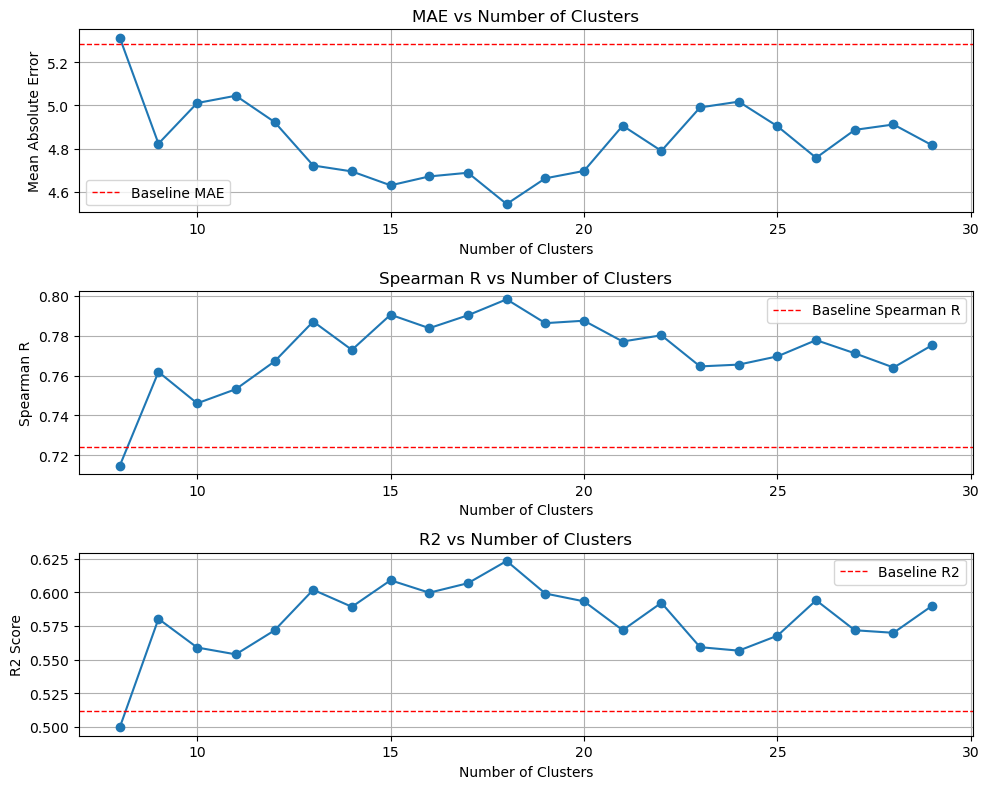

In [114]:
# plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(clusters, maes, marker='o')
plt.grid()
plt.axhline(y=5.2828, color='r', linestyle='--', label='Baseline MAE', linewidth=1)
plt.title('MAE vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(clusters, spearmans, marker='o')
plt.grid()
plt.title('Spearman R vs Number of Clusters')
plt.axhline(y=0.7240, color='r', linestyle='--', label='Baseline Spearman R', linewidth=1)
plt.xlabel('Number of Clusters')
plt.ylabel('Spearman R')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(clusters, r2s, marker='o')
plt.grid()
plt.title('R2 vs Number of Clusters')
plt.axhline(y=0.5118, color='r', linestyle='--', label='Baseline R2', linewidth=1)
plt.xlabel('Number of Clusters')
plt.ylabel('R2 Score')
plt.legend()
plt.tight_layout()
plt.show()


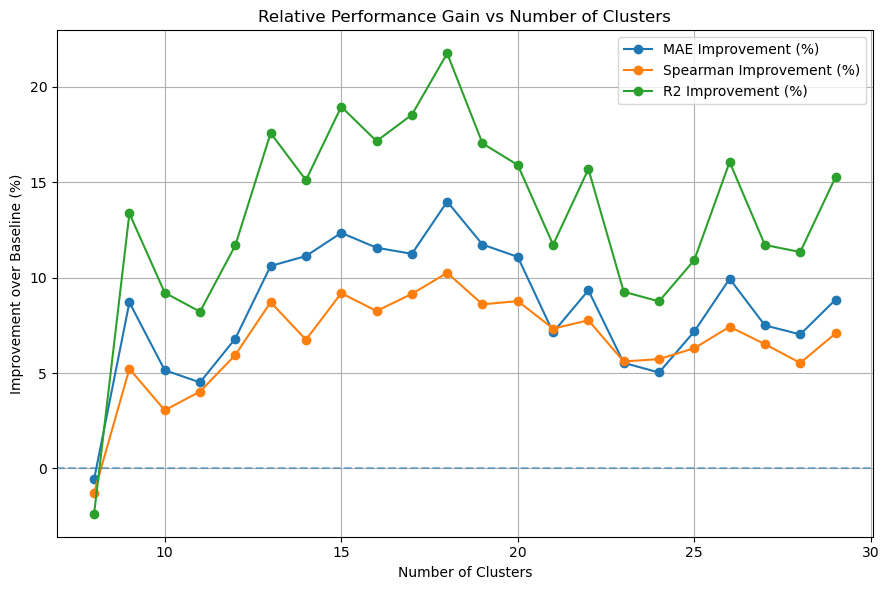

In [112]:
import numpy as np
import matplotlib.pyplot as plt

# Baselines
mae_base = 5.2828
spearman_base = 0.7240
r2_base = 0.5118

# Convert to % improvement (higher is better for all)
mae_imp = (mae_base - np.array(maes)) / mae_base * 100
spearman_imp = (np.array(spearmans) - spearman_base) / spearman_base * 100
r2_imp = (np.array(r2s) - r2_base) / r2_base * 100

plt.figure(figsize=(9,6))

plt.plot(clusters, mae_imp, marker='o', label='MAE Improvement (%)')
plt.plot(clusters, spearman_imp, marker='o', label='Spearman Improvement (%)')
plt.plot(clusters, r2_imp, marker='o', label='R2 Improvement (%)')

plt.axhline(0, linestyle='--', alpha=0.5)
plt.xlabel('Number of Clusters')
plt.ylabel('Improvement over Baseline (%)')
plt.title('Relative Performance Gain vs Number of Clusters')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
for seed in random.sample(range(100), 1):
    #with normal k means
    print('seed:', seed)
    vocab = KinematicVocabulary(n_clusters=10, random_state=seed, model_type='kmeans', n_init=10,
                                feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                log_feats=['total_path','path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                power_feats=None)

    # => either go with this or total_path instead of vel_p90, but not both since they are redundant

    selector = NestedFeatureSelector(
        top_n=4, 
        pr2_threshold=0.00,         # how much additional variance is needed to be selected
        corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
    )

    model = RidgeCV(alphas=np.logspace(-1, 2, 20))

    #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


    results_df, profile_df = run_hybrid_vocabulary_loso(
                df_videos=df_pc1_features, 
                df_windows=df_window, 
                primary_features=pc1_features, 
                extra_features=['velocity_corr'], 
                target_col='QRS_Overal', 
                surgeon_col='Participant Number', 
                video_col='video_id', 
                vocab=vocab,
                selector=selector,
                model=model
    )

seed: 29


Running LOSO: 100%|██████████| 28/28 [01:11<00:00,  2.54s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.4539 ± 3.6393
Spearman R: 0.7806
Overall R2: 0.6182
Number of selected features: 4.00 ± 0.00


# Without Velocity Corr

In [26]:
#all_fold_centroids = []

for seed in random.sample(range(100), 5):
    #with normal k means, seed 62 is good!
    print('seed:', seed)
    vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=10,
                                feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                power_feats=None)

    # => either go with this or total_path instead of vel_p90, but not both since they are redundant

    selector = NestedFeatureSelector(
        top_n=5, 
        pr2_threshold=0.00,         # how much additional variance is needed to be selected
        corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
    )

    model = RidgeCV(alphas=np.logspace(-1, 2, 20))

    #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


    results_df, profile_df, fold_centroids = run_hybrid_vocabulary_loso(
                df_videos=df_pc1_features, 
                df_windows=df_window, 
                primary_features=pc1_features, 
                extra_features=['Case_1', 'Case_3'], 
                target_col='QRS_Overal', 
                surgeon_col='Participant Number', 
                video_col='video_id', 
                vocab=vocab,
                selector=selector,
                model=model
    )
    for centroid in fold_centroids:
        d=1
        #all_fold_centroids.append(centroid)


# with my feature selector


seed: 17


Running LOSO: 100%|██████████| 28/28 [01:00<00:00,  2.17s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7653 ± 3.8571
Spearman R: 0.7562
Overall R2: 0.5662
Number of selected features: 5.00 ± 0.00
seed: 92


Running LOSO: 100%|██████████| 28/28 [01:03<00:00,  2.28s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8838 ± 3.9677
Spearman R: 0.7388
Overall R2: 0.5430
Number of selected features: 5.00 ± 0.00
seed: 89


...


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8311 ± 3.7895
Spearman R: 0.7520
Overall R2: 0.5649
Number of selected features: 5.00 ± 0.00
seed: 27


Running LOSO: 100%|██████████| 28/28 [00:54<00:00,  1.95s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.9076 ± 3.9969
Spearman R: 0.7374
Overall R2: 0.5376
Number of selected features: 5.00 ± 0.00
seed: 59


Running LOSO: 100%|██████████| 28/28 [01:04<00:00,  2.30s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7194 ± 3.8968
Spearman R: 0.7551
Overall R2: 0.5677
Number of selected features: 5.00 ± 0.00


In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV, Lasso

for n_cluster in range(6, 24, 2):
    print("=========", n_cluster, "========")
    for seed in random.sample(range(100), 1):
        #with normal k means, seed 62 is good!
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=10,
                                    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)
        
        #model = RidgeCV(alphas=np.logspace(-1, 1, 20))

        #model = ElasticNetCV(alphas=np.logspace(-1, 1, 20))

        model = LassoCV(alphas=np.logspace(-1, 1, 20))


        results_df, profile_df, fold_centroids = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['Case_1', 'Case_3'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id',
                    vocab=vocab,
                    model=model,
                    use_baseline=False  # NEW: Disable baseline to focus on BoW features only
        )
        for centroid in fold_centroids:
            d=1
            #all_fold_centroids.append(centroid)


========= 6 ========
seed: 33


Running LOSO: 100%|██████████| 28/28 [00:27<00:00,  1.02it/s]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 7.4740 ± 4.5721
Spearman R: 0.3060
Overall R2: 0.1140
Number of selected features: 3.00 ± 0.53
========= 8 ========
seed: 9


Running LOSO: 100%|██████████| 28/28 [00:30<00:00,  1.09s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 7.3787 ± 4.7111
Spearman R: 0.3172
Overall R2: 0.1154
Number of selected features: 3.32 ± 2.11
========= 10 ========
seed: 44


...


=== Hybrid SurgeMe LOSO Summary ===
MAE: 6.8354 ± 4.4686
Spearman R: 0.4415
Overall R2: 0.2302
Number of selected features: 5.21 ± 2.45
========= 20 ========
seed: 46


Running LOSO: 100%|██████████| 28/28 [00:54<00:00,  1.95s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 6.7523 ± 4.2873
Spearman R: 0.4556
Overall R2: 0.2616
Number of selected features: 5.61 ± 1.88
========= 22 ========
seed: 80


Running LOSO: 100%|██████████| 28/28 [00:56<00:00,  2.03s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 6.7624 ± 4.4567
Spearman R: 0.4422
Overall R2: 0.2429
Number of selected features: 6.36 ± 1.42


In [366]:
all_fold_centroids = []

for seed in random.sample(range(100), 1):
    #with normal k means, seed 62 is good!
    print('seed:', seed)
    vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=10,
                                feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                power_feats=None)
    
    #model = RidgeCV(alphas=np.logspace(-1, 1, 20))

    #model = ElasticNetCV(alphas=np.logspace(-1, 1, 20))

    model = LassoCV(alphas=np.logspace(-1, 1, 30))


    results_df, profile_df, fold_centroids = run_hybrid_vocabulary_loso(
                df_videos=df_pc1_features, 
                df_windows=df_window, 
                primary_features=pc1_features, 
                extra_features=['Case_1', 'Case_3'], 
                target_col='QRS_Overal', 
                surgeon_col='Participant Number', 
                video_col='video_id',
                vocab=vocab,
                model=model,
                use_baseline=True  # NEW: Disable baseline to focus on BoW features only
    )
    for centroid in fold_centroids:
        all_fold_centroids.append(centroid)

seed: 66


Running LOSO: 100%|██████████| 28/28 [01:01<00:00,  2.21s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7396 ± 3.7598
Spearman R: 0.7630
Overall R2: 0.5776
Number of selected features: 3.61 ± 0.62

=== Baseline Feature Selection Consistency ===
PC1: Selected in 100.0% of folds
Case_1: Selected in 0.0% of folds
Case_3: Selected in 0.0% of folds


"While standard KMeans provides a more precise geometric minimization of inertia, MiniBatchKMeans was found to yield superior predictive performance. This suggests that the stochastic nature of the mini-batch updates provides a regularizing effect, preventing the 'cluster collapse' into high-density expert regions and allowing the Bag-of-Words model to better generalize across surgeons in the LOSO cross-validation." 

"While MiniBatchKMeans provided initial regularization through stochastic noise, Standard KMeans with a refined cluster count (k=24) provided a more stable geometric partitioning of the surgical motion space. This transition reduced the variance across random initializations from ±0.04 to ±0.01 in R 
2
 , suggesting that the model successfully converged to a consistent surgical 'vocabulary' that generalizes across different surgeons."

### Elbow for cluster number justification

In [90]:
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt
from tqdm import tqdm

# Note: Silhouette is slow on large data, use a subsample of 10,000 frames
def plot_silhouette(df_processed, k_range=range(2, 26, 1)):
    scores = []
    # Subsample for speed
    X_sub = df_processed[np.random.choice(df_processed.shape[0], 10000, replace=False)]
    #X_sub = df_processed.copy()
    
    for k in tqdm(k_range):
        km = KMeans(n_clusters=k, n_init=5, random_state=42).fit(X_sub)
        score = silhouette_score(X_sub, km.labels_)
        scores.append(score)
        
    plt.plot(k_range, scores, 'ro-')
    plt.title('Silhouette Score (Cluster Distinctness)')
    plt.show()

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:41<00:00,  1.74s/it]


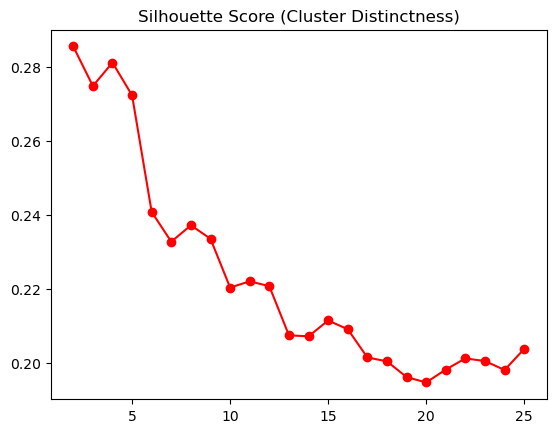

In [91]:
# elbow
X_all = vocab._preprocess(df_window, fit=True)
plot_silhouette(X_all)

array([[<Axes: title={'center': 'path_ratio'}>,
        <Axes: title={'center': 'spatial_spread'}>],
       [<Axes: title={'center': 'palm_area_cv'}>,
        <Axes: title={'center': 'sparc'}>]], dtype=object)

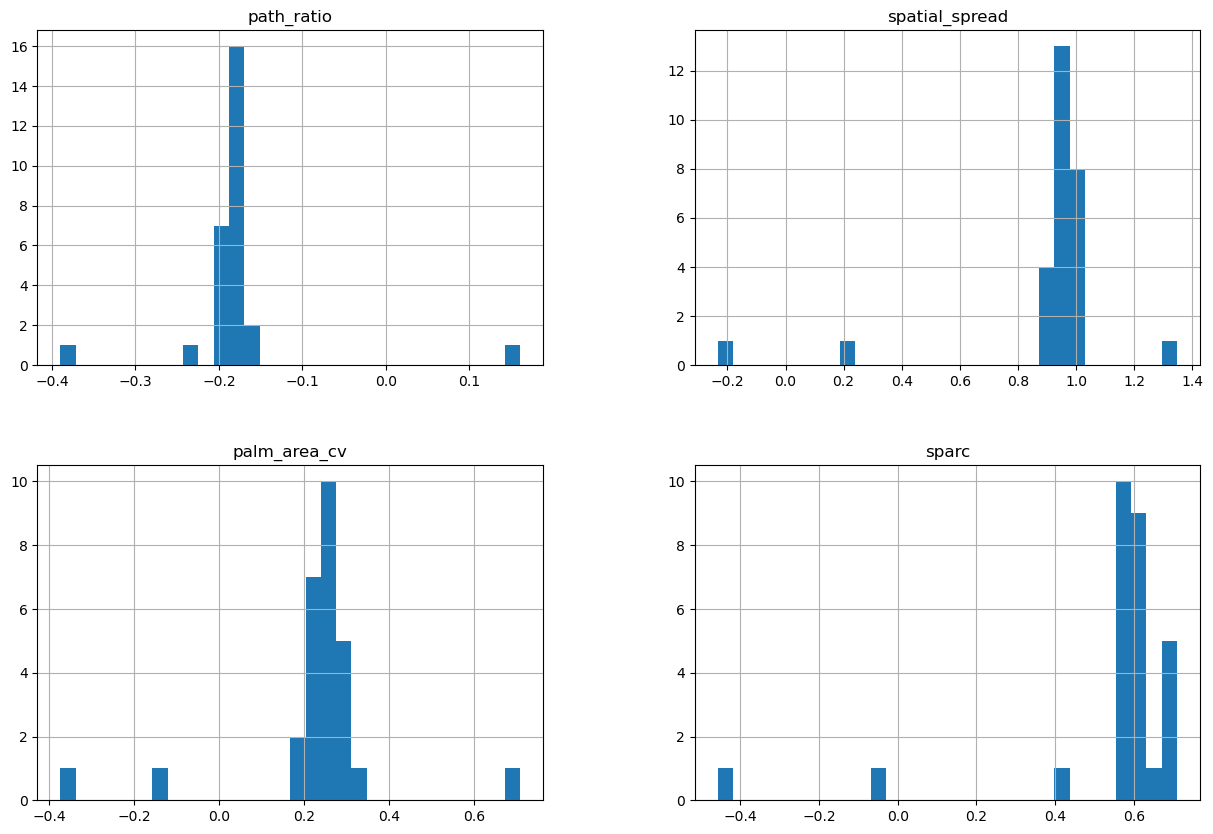

In [42]:

idx = profile_df.groupby('Surgeon_Out')['PR2'].idxmax()
profile_df.loc[idx][vocab.feature_cols].hist(bins=30, figsize=(15, 10))

In [ ]:
# group by index and make a plot for all selected 

array([[<Axes: title={'center': 'path_ratio'}>,
        <Axes: title={'center': 'spatial_spread'}>],
       [<Axes: title={'center': 'palm_area_cv'}>,
        <Axes: title={'center': 'sparc'}>]], dtype=object)

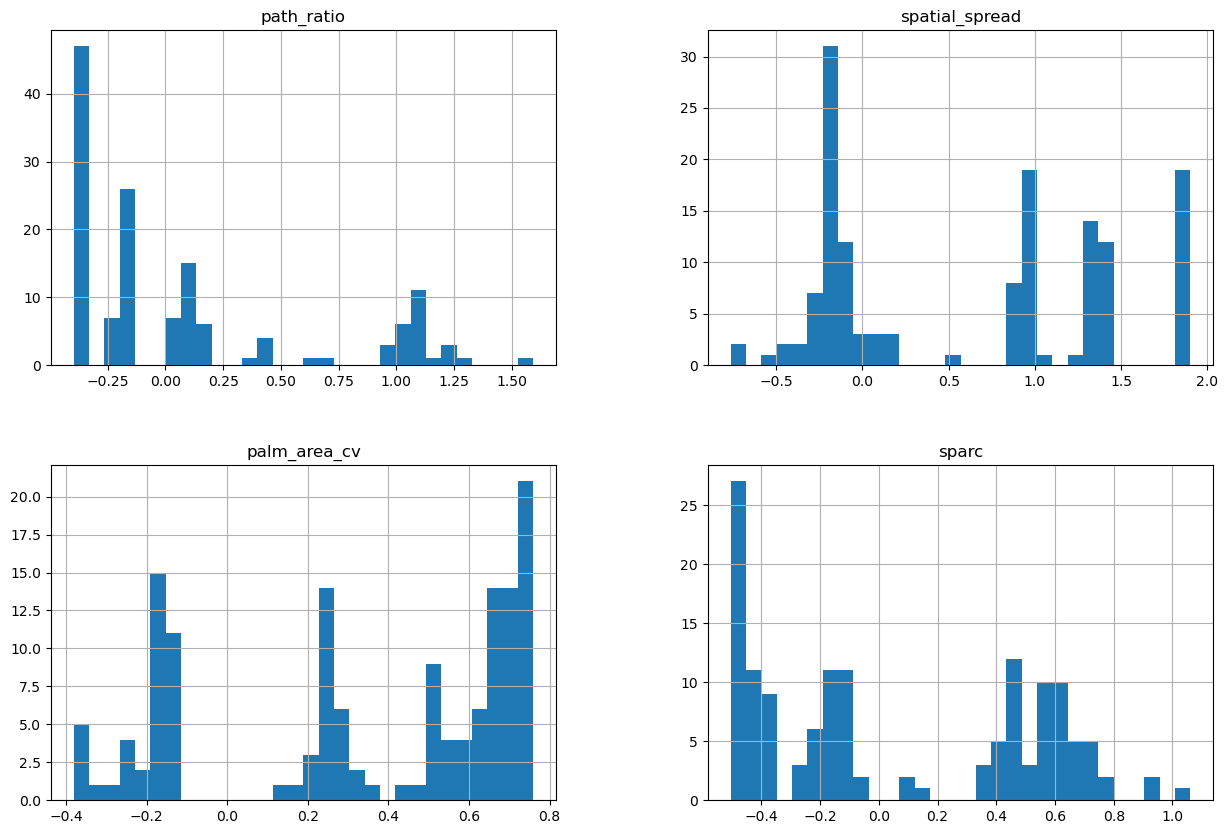

In [38]:
# histogrames of each feat:
profile_df[vocab.feature_cols].hist(bins=30, figsize=(15, 10))

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def identify_consensus_surgemes(profile_df, feature_cols, n_meta_clusters=None):
    """
    Groups the selected centroids from all LOSO folds into 
    consensus 'Meta-SurgeMes'.
    """
    # 1. Extract the coordinates of all selected centroids
    X_meta = profile_df[feature_cols].values
    
    # 2. Determine number of Meta-Clusters (if not provided)
    # Usually, if you have 16 clusters per fold, you might find 
    # 3-6 'consensus' behaviors that actually drive the score.
    if n_meta_clusters is None:
        # Simple heuristic: find the best silhouette score
        best_n = 2
        best_s = -1
        for n in range(2, 20):
            km = KMeans(n_clusters=n, random_state=42).fit(X_meta)
            s = silhouette_score(X_meta, km.labels_)
            print(f"Silhouette for n={n}: {s:.4f}")
            if s > best_s:
                best_s = s
                best_n = n
        n_meta_clusters = best_n
        print(f"Optimal number of Meta-Clusters: {n_meta_clusters} with silhouette score: {best_s:.4f}")

    # 3. Fit Meta-Clustering
    meta_km = KMeans(n_clusters=n_meta_clusters, random_state=42)
    profile_df['Meta_Cluster_ID'] = meta_km.fit_transform(X_meta).argmin(axis=1) # Get labels
    
    # 4. Create the 'Consensus Table'
    # This averages the kinematic signatures of each consensus behavior
    consensus_table = profile_df.groupby('Meta_Cluster_ID')[feature_cols].mean()
    
    # 5. Calculate 'Selection Frequency'
    # How many folds out of the total LOSO folds picked this type of behavior?
    # This is a proxy for how 'universal' the behavior is.
    counts = profile_df['Meta_Cluster_ID'].value_counts()
    consensus_table['Fold_Frequency'] = counts / profile_df['Surgeon_Out'].nunique()
    
    return consensus_table, profile_df

In [40]:
consensus_table, annotated_profiles = identify_consensus_surgemes(profile_df, feature_cols=vocab.feature_cols)

Silhouette for n=2: 0.5511
Silhouette for n=3: 0.6001
Silhouette for n=4: 0.6816
Silhouette for n=5: 0.7406
Silhouette for n=6: 0.7850
Silhouette for n=7: 0.8231
Silhouette for n=8: 0.8285
Silhouette for n=9: 0.8447
Silhouette for n=10: 0.8494
Silhouette for n=11: 0.7804
Silhouette for n=12: 0.7840
Silhouette for n=13: 0.7915
Silhouette for n=14: 0.7940
Silhouette for n=15: 0.8016
Silhouette for n=16: 0.7246
Silhouette for n=17: 0.6732
Silhouette for n=18: 0.6572
Silhouette for n=19: 0.5755
Optimal number of Meta-Clusters: 10 with silhouette score: 0.8494


In [254]:
consensus_table

,total_path,path_ratio,spatial_spread,palm_area_cv,sparc,Fold_Frequency
Meta_Cluster_ID,,,,,,
0,0.121636,-0.303128,0.604569,-0.231432,-0.454517,0.428571
1,1.017818,-0.319230,1.611045,0.364328,-0.330158,1.000000
2,0.070158,-0.108210,0.307684,-0.104613,0.673518,1.000000
3,0.075939,0.241208,0.079297,0.786283,-0.063874,0.142857
4,-0.384271,0.999762,-0.660291,-0.131526,0.153373,0.214286
5,0.212401,0.858883,-0.228960,0.561309,1.377821,0.214286
6,0.430032,-0.297356,0.940873,-0.052638,-0.402068,0.357143
7,0.542152,2.060127,-0.050742,0.540170,0.420737,0.035714
8,-0.140174,0.009903,0.020076,0.793045,-0.122460,0.607143


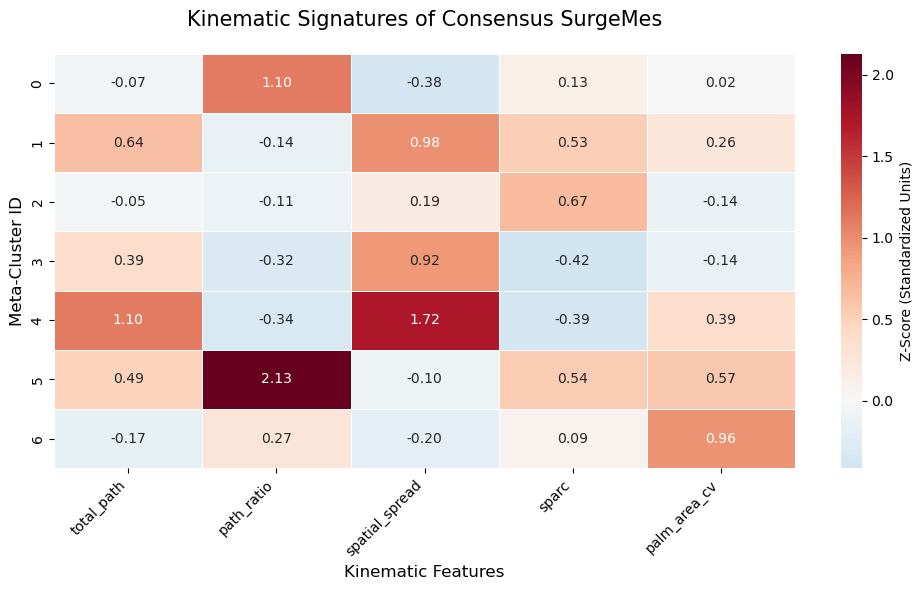

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_consensus_heatmap(consensus_table, feature_cols):
    """
    Plots a heatmap of the kinematic signatures of Consensus SurgeMes.
    """
    # 1. Isolate the kinematic features for the heatmap
    # We exclude 'Fold_Frequency' and 'PR2' for the main colors
    plot_data = consensus_table[feature_cols]
    
    # 2. Setup the figure
    plt.figure(figsize=(10, 6))
    
    # 3. Create Heatmap
    # cmap='RdBu_r' is perfect for Z-scores (Red = High, Blue = Low)
    # center=0 ensures that the "average" is white
    sns.heatmap(
        plot_data, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu_r', 
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Z-Score (Standardized Units)'}
    )
    
    plt.title('Kinematic Signatures of Consensus SurgeMes', fontsize=15, pad=20)
    plt.xlabel('Kinematic Features', fontsize=12)
    plt.ylabel('Meta-Cluster ID', fontsize=12)
    
    # Optional: Rotate labels for better fit
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Execution
consensus_table, profile_df = identify_consensus_surgemes(profile_df, vocab.feature_cols)
plot_consensus_heatmap(consensus_table, vocab.feature_cols)

# Align Fold Centroids To A Global Template

In [409]:
all_fold_centroids = []
vocab = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=10,
                            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            power_feats=None)

#model = RidgeCV(alphas=np.logspace(-1, 1, 20))

#model = ElasticNetCV(alphas=np.logspace(-1, 1, 20))

model = LassoCV(alphas=np.logspace(-1, 1, 30))


results_df, profile_df, fold_centroids = run_hybrid_vocabulary_loso(
            df_videos=df_pc1_features, 
            df_windows=df_window, 
            primary_features=pc1_features, 
            extra_features=['Case_1', 'Case_3'], 
            target_col='QRS_Overal', 
            surgeon_col='Participant Number', 
            video_col='video_id',
            vocab=vocab,
            model=model,
            use_baseline=True  # NEW: Disable baseline to focus on BoW features only
)
for centroid in fold_centroids:
    all_fold_centroids.append(centroid)

Running LOSO:   0%|          | 0/28 [00:00<?, ?it/s]

Running LOSO: 100%|██████████| 28/28 [01:10<00:00,  2.52s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7128 ± 3.7098
Spearman R: 0.7679
Overall R2: 0.5848
Number of selected features: 3.75 ± 0.63

=== Baseline Feature Selection Consistency ===
PC1: Selected in 100.0% of folds
Case_1: Selected in 0.0% of folds
Case_3: Selected in 0.0% of folds


In [389]:
df_stability

,fold,cluster_id,path_ratio,spatial_spread,palm_area_cv,sparc
0,0,0,0.022763,-0.583548,-0.394460,1.224768
1,0,1,-0.328708,0.476722,-0.307301,-0.489536
2,0,2,0.807392,0.429163,0.303024,-0.166082
3,0,3,0.406294,-0.152694,0.718906,0.878435
4,0,4,0.017393,-0.744427,-0.447794,0.260705
...,...,...,...,...,...,...
2011,111,13,-0.237300,-0.313777,-0.446920,-0.466217
2012,111,14,-0.358416,1.876862,0.544412,-0.396307
2013,111,15,1.196287,-0.034367,0.751511,0.052276
2014,111,16,-0.178034,0.926901,0.274953,0.683992


In [393]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns
import matplotlib.pyplot as plt

def align_fold_centroids(global_centroids, fold_centroids_list):
    """
    global_centroids: (K, 4) array from K-Means on the full dataset.
    fold_centroids_list: A list of (K, 4) arrays, one for each of your 28 LOSO folds.
    """
    aligned_data = []
    K = global_centroids.shape[0]

    for fold_idx, f_cents in enumerate(fold_centroids_list):
        # 1. Compute distance matrix between Global and this Fold's centroids
        # cost_matrix[i, j] is the distance between Global Cluster i and Fold Cluster j
        cost_matrix = euclidean_distances(global_centroids, f_cents)
        
        # 2. Find the optimal one-to-one mapping (Hungarian Algorithm)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        # 3. Reorder the fold centroids to match the global template order
        # col_ind tells us which index in f_cents matches 0, 1, 2... in global
        for i, j in zip(row_ind, col_ind):
            aligned_data.append({
                'fold': fold_idx,
                'cluster_id': i,  # This is the "Global Name"
                'path_ratio': f_cents[j, 0],
                'spatial_spread': f_cents[j, 1],
                'palm_area_cv': f_cents[j, 2],
                'sparc': f_cents[j, 3]
            })
            
    return pd.DataFrame(aligned_data)


def plot_surgeme_stability(df_stability, global_centroids):
    """
    Plots a 2x2 grid of boxplots showing the stability of each kinematic 
    feature across the 28 LOSO folds for each cluster and overlays the
    global centroid value as a black dot.
    """
    features = ['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc']
    
    titles = ['Path Ratio (Efficiency)', 'Spatial Spread (Economy)', 
              'SPARC (Smoothness)', 'Palm Area CV (Pose Stability)']
    
    sns.set_context("paper", font_scale=1.2)
    plt.style.use("seaborn-v0_8-whitegrid")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for i, feat in enumerate(features):

        # Boxplots across folds
        sns.boxplot(
            data=df_stability,
            x='cluster_id',
            y=feat,
            hue='cluster_id',
            ax=axes[i],
            palette="viridis",
            legend=False,
            fliersize=2,
            linewidth=1.2
        )

        # Mean indicator
        """sns.pointplot(
            data=df_stability,
            x='cluster_id',
            y=feat,
            ax=axes[i],
            color='red',
            markersize=4,
            linestyle='none',
            errorbar=None,
            estimator=np.mean
        )"""

        # ---- GLOBAL CENTROID DOT ----
        x_positions = np.arange(global_centroids.shape[0])
        y_positions = global_centroids[:, i]

        axes[i].scatter(
            x_positions,
            y_positions,
            color="red",
            s=15,
            marker="o",
            label="Global centroid",
            zorder=10
        )

        axes[i].set_title(titles[i], fontweight='bold', pad=10)
        axes[i].set_xlabel("Surgeme (Global Cluster ID)")
        axes[i].set_ylabel("Feature Value")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    fig.suptitle("Kinematic Stability of Surgeme Vocabulary Across 28 LOSO Folds", fontsize=16)

    # Show legend once
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.show()

In [391]:
# do different seed produce very similar global scale clusters
vocab_ref = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=20,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )

vocab_ref.fit(df_window)

global_centers = vocab_ref.model.cluster_centers_

comp_cluster_centers = []

for seed in tqdm(random.sample(range(40), 1)):
    vocab_temp = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=20,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )
    vocab_temp.fit(df_window)
    comp_cluster_centers.append(vocab_temp.model.cluster_centers_)

100%|██████████| 1/1 [00:03<00:00,  3.70s/it]


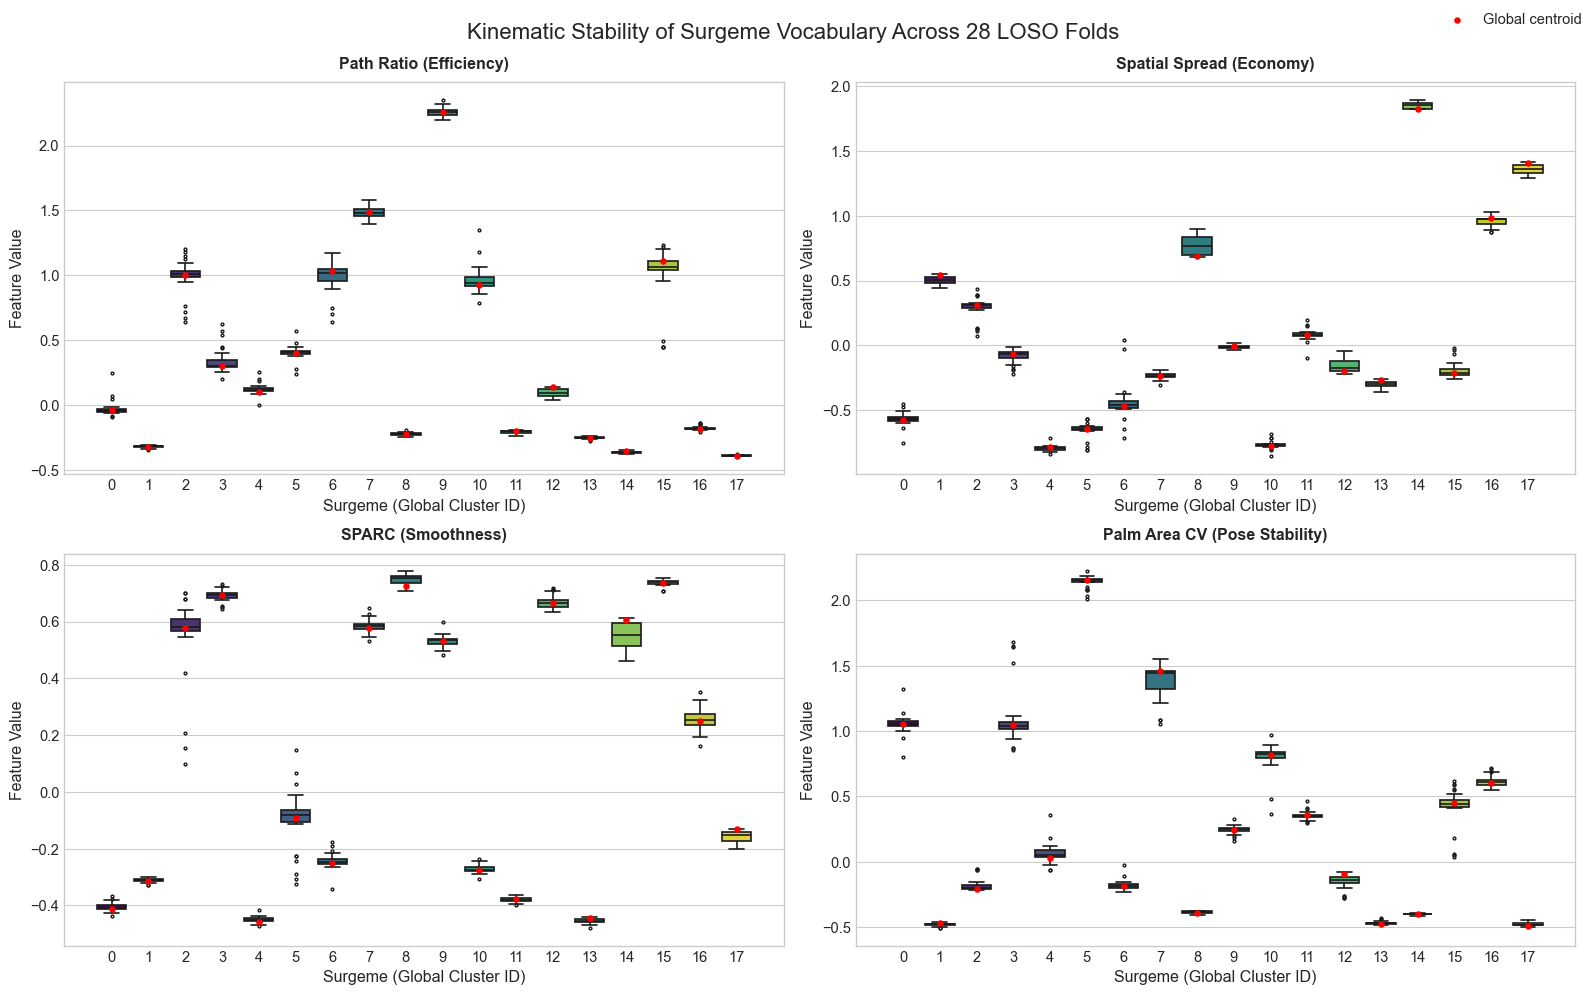

In [410]:
global_centers = vocab_ref.model.cluster_centers_
df_stability = align_fold_centroids(global_centers, all_fold_centroids)

# Let's look at 'sparc' stability across the 18 clusters
plot_surgeme_stability(df_stability, global_centers)

In [ ]:
# for each surgeon rank feautres by weight magnitude and select the n_th

# top bow idx = 16 (negative), 0 (negative), 12 (positive)
profile_df.loc[profile_df.groupby('Surgeon_Out')['Weight'].apply(lambda x: x.sort_values(ascending=False).index[0]).values]

,Surgeon_Out,Feature_Name,Weight,path_ratio,spatial_spread,palm_area_cv,sparc
0,1,SurgeMe_1,0.902382,0.129451,-0.194739,0.669593,-0.100354
6,2,SurgeMe_12,0.957636,0.127165,-0.224281,0.658382,-0.137173
9,3,SurgeMe_4,0.892672,0.125327,-0.185878,0.644594,-0.115195
15,4,SurgeMe_17,0.828722,0.054389,-0.048546,0.647999,-0.278058
18,5,SurgeMe_14,0.818251,0.089597,-0.163683,0.663908,-0.151788
21,6,SurgeMe_8,0.936472,0.047317,-0.069559,0.633381,-0.258381
25,7,SurgeMe_12,0.916088,0.138010,-0.199858,0.677852,-0.107763
30,9,SurgeMe_17,0.468953,0.133445,-0.187950,0.650787,-0.109014
31,10,SurgeMe_0,0.869817,0.037387,-0.045657,0.681090,-0.265490
36,11,SurgeMe_5,0.837705,0.071342,-0.137624,0.672245,-0.151498


In [415]:
df_stability[df_stability['cluster_id'] == 16][['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc']].describe()

,path_ratio,spatial_spread,palm_area_cv,sparc
count,28.000000,28.000000,28.000000,28.000000
mean,-0.178023,0.955052,0.256564,0.618429
std,0.016608,0.040995,0.038061,0.043917
min,-0.207897,0.873039,0.163427,0.545713
25%,-0.186664,0.937764,0.237214,0.588983
50%,-0.183433,0.972745,0.252951,0.609704
75%,-0.174280,0.979290,0.275605,0.627242
max,-0.138783,1.030566,0.351503,0.716681


In [427]:
df_stability[df_stability['cluster_id'] == 12][['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc']].describe()

,path_ratio,spatial_spread,palm_area_cv,sparc
count,28.000000,28.000000,28.000000,28.000000
mean,0.097434,-0.154529,0.667234,-0.152399
std,0.032155,0.050468,0.023058,0.056224
min,0.037387,-0.224281,0.633381,-0.278058
25%,0.071272,-0.194951,0.650647,-0.165112
50%,0.095432,-0.172356,0.664920,-0.139620
75%,0.127481,-0.124613,0.675166,-0.112904
max,0.141080,-0.045657,0.719746,-0.075164


### **Lasso CV directly with all BoWs**

First with velocity corr


Then without it

In [143]:
from sklearn.linear_model import LassoCV, ElasticNetCV, ElasticNet

for seed in random.sample(range(100), 3):
    print('seed:', seed)
    vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=5,
                                feature_cols=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                                log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'])

    #model = ElasticNet(alpha=0.5, l1_ratio=0.5)
    #model = ElasticNetCV(alphas=np.logspace(-1, 2, 30), l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9])
    model = LassoCV(alphas=np.logspace(-1, 5, 30))

    results_df, profile_df, _ = run_hybrid_vocabulary_loso(
                df_videos=df_pc1_features, 
                df_windows=df_window, 
                primary_features=pc1_features, 
                extra_features=['velocity_corr'], 
                target_col='QRS_Overal', 
                surgeon_col='Participant Number', 
                video_col='video_id', 
                vocab=vocab,
                model=model
)

seed: 72


Running LOSO: 100%|██████████| 28/28 [00:49<00:00,  1.78s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7596 ± 3.8156
Spearman R: 0.7611
Overall R2: 0.5705
Number of selected features: 18.00 ± 0.00
seed: 64


Running LOSO: 100%|██████████| 28/28 [00:52<00:00,  1.89s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7132 ± 3.8302
Spearman R: 0.7579
Overall R2: 0.5743
Number of selected features: 18.00 ± 0.00
seed: 86


Running LOSO: 100%|██████████| 28/28 [00:46<00:00,  1.68s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7608 ± 3.8682
Spearman R: 0.7532
Overall R2: 0.5657
Number of selected features: 18.00 ± 0.00


In [16]:
from sklearn.linear_model import LassoCV, ElasticNetCV, ElasticNet

for seed in random.sample(range(100), 3):
    print('seed:', seed)
    vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=10,
                                feature_cols=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                                log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'])

    #model = ElasticNet(alpha=0.5, l1_ratio=0.5)
    #model = ElasticNetCV(alphas=np.logspace(-1, 2, 30), l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9])
    model = LassoCV(alphas=np.logspace(-1, 5, 30))

    results_df, profile_df, _ = run_hybrid_vocabulary_loso(
                df_videos=df_pc1_features, 
                df_windows=df_window, 
                primary_features=pc1_features, 
                extra_features=[], 
                target_col='QRS_Overal', 
                surgeon_col='Participant Number', 
                video_col='video_id', 
                vocab=vocab,
                model=model
)

seed: 6


Running LOSO: 100%|██████████| 28/28 [00:49<00:00,  1.78s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7452 ± 3.7650
Spearman R: 0.7598
Overall R2: 0.5765
Number of selected features: 18.00 ± 0.00
seed: 48


Running LOSO: 100%|██████████| 28/28 [00:58<00:00,  2.09s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7416 ± 3.7955
Spearman R: 0.7582
Overall R2: 0.5742
Number of selected features: 18.00 ± 0.00
seed: 68


Running LOSO: 100%|██████████| 28/28 [00:46<00:00,  1.66s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7581 ± 3.7645
Spearman R: 0.7624
Overall R2: 0.5751
Number of selected features: 18.00 ± 0.00


In [17]:
# with case type added
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_pc1_features['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_pc1_features.columns):
    df_pc1_features = pd.concat([df_pc1_features, df_case_onehot], axis=1)


for seed in random.sample(range(100), 3):
    print('seed:', seed)
    vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=10,
                                feature_cols=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                                log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'])

    #model = ElasticNet(alpha=0.5, l1_ratio=0.5)
    #model = ElasticNetCV(alphas=np.logspace(-1, 2, 30), l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9])
    model = LassoCV(alphas=np.logspace(-1, 5, 30))

    results_df, profile_df, _ = run_hybrid_vocabulary_loso(
                df_videos=df_pc1_features, 
                df_windows=df_window, 
                primary_features=pc1_features, 
                extra_features=['Case_1', 'Case_3'], 
                target_col='QRS_Overal', 
                surgeon_col='Participant Number', 
                video_col='video_id', 
                vocab=vocab,
                model=model
    )

seed: 53


Running LOSO: 100%|██████████| 28/28 [00:58<00:00,  2.08s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.6777 ± 3.7911
Spearman R: 0.7642
Overall R2: 0.5816
Number of selected features: 18.00 ± 0.00
seed: 59


Running LOSO: 100%|██████████| 28/28 [00:50<00:00,  1.80s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.6915 ± 3.7952
Spearman R: 0.7625
Overall R2: 0.5797
Number of selected features: 18.00 ± 0.00
seed: 12


Running LOSO: 100%|██████████| 28/28 [00:47<00:00,  1.70s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7314 ± 3.7249
Spearman R: 0.7674
Overall R2: 0.5815
Number of selected features: 18.00 ± 0.00


In [155]:
vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=5,
                            feature_cols=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'])

model = ElasticNet(alpha=0.5, l1_ratio=0.9)
#model = ElasticNetCV(alphas=np.logspace(-1, 2, 30), l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9])
#model = LassoCV(alphas=np.logspace(-1, 5, 30))

results_df, profile_df, _ = run_hybrid_vocabulary_loso(
            df_videos=df_pc1_features, 
            df_windows=df_window, 
            primary_features=pc1_features, 
            extra_features=[], 
            target_col='QRS_Overal', 
            surgeon_col='Participant Number', 
            video_col='video_id', 
            vocab=vocab,
            model=model)

Running LOSO: 100%|██████████| 28/28 [00:47<00:00,  1.70s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7288 ± 3.8781
Spearman R: 0.7577
Overall R2: 0.5683
Number of selected features: 18.00 ± 0.00


In [239]:
# same but with k means instad of minibatch
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import random

results = []
for n_cluster in range(6, 26, 2):
    print("=========", n_cluster, "========")
    results.append({n_cluster: {'mae': None, 'spearman': None, 'R2': None}})
    res = {'mae':[], 'spearman': [], 'R2': []}
    for seed in random.sample(range(100), 2):
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=10,
                                    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)

        # => either go with this or total_path instead of vel_p90, but not both since they are redundant

        model = LassoCV(alphas=np.logspace(-1, 1, 20))

        #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


        results_df, profile_df, _ = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['Case_1', 'Case_3'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id', 
                    vocab=vocab,
                    model=model
        )

        # compute seed metrics
        mae = mean_absolute_error(results_df['True'], results_df['Pred'])
        std = np.std(np.abs(results_df['True'] - results_df['Pred']))
        spearman = spearmanr(results_df['True'], results_df['Pred'])[0]
        r2 = r2_score(results_df['True'], results_df['Pred'])

        res['mae'].append(mae)
        res['spearman'].append(spearman)
        res['R2'].append(r2)
    
    # compute mean metrics across seeds for this n_cluster
    results[-1][n_cluster]['mae'] = np.mean(res['mae'])
    results[-1][n_cluster]['spearman'] = np.mean(res['spearman'])
    results[-1][n_cluster]['R2'] = np.mean(res['R2'])

========= 6 ========
seed: 22


Running LOSO: 100%|██████████| 28/28 [00:34<00:00,  1.22s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.1263 ± 4.2643
Spearman R: 0.6852
Overall R2: 0.4868
Number of selected features: 3.25 ± 0.57

=== Baseline Feature Selection Consistency ===
PC1: Selected in 100.0% of folds
Case_1: Selected in 7.1% of folds
Case_3: Selected in 7.1% of folds
seed: 23


Running LOSO: 100%|██████████| 28/28 [00:31<00:00,  1.13s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.1311 ± 4.2662
Spearman R: 0.6839
Overall R2: 0.4860
Number of selected features: 3.18 ± 0.60

=== Baseline Feature Selection Consistency ===
PC1: Selected in 100.0% of folds
Case_1: Selected in 7.1% of folds
Case_3: Selected in 7.1% of folds
========= 8 ========
seed: 89


...


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8939 ± 3.8108
Spearman R: 0.7479
Overall R2: 0.5559
Number of selected features: 4.54 ± 1.48

=== Baseline Feature Selection Consistency ===
PC1: Selected in 100.0% of folds
Case_1: Selected in 0.0% of folds
Case_3: Selected in 0.0% of folds
========= 24 ========
seed: 12


Running LOSO: 100%|██████████| 28/28 [00:56<00:00,  2.02s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8534 ± 3.8318
Spearman R: 0.7415
Overall R2: 0.5587
Number of selected features: 3.75 ± 1.21

=== Baseline Feature Selection Consistency ===
PC1: Selected in 100.0% of folds
Case_1: Selected in 0.0% of folds
Case_3: Selected in 0.0% of folds
seed: 45


Running LOSO: 100%|██████████| 28/28 [00:56<00:00,  2.03s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8741 ± 3.9933
Spearman R: 0.7330
Overall R2: 0.5417
Number of selected features: 3.71 ± 0.96

=== Baseline Feature Selection Consistency ===
PC1: Selected in 100.0% of folds
Case_1: Selected in 0.0% of folds
Case_3: Selected in 0.0% of folds


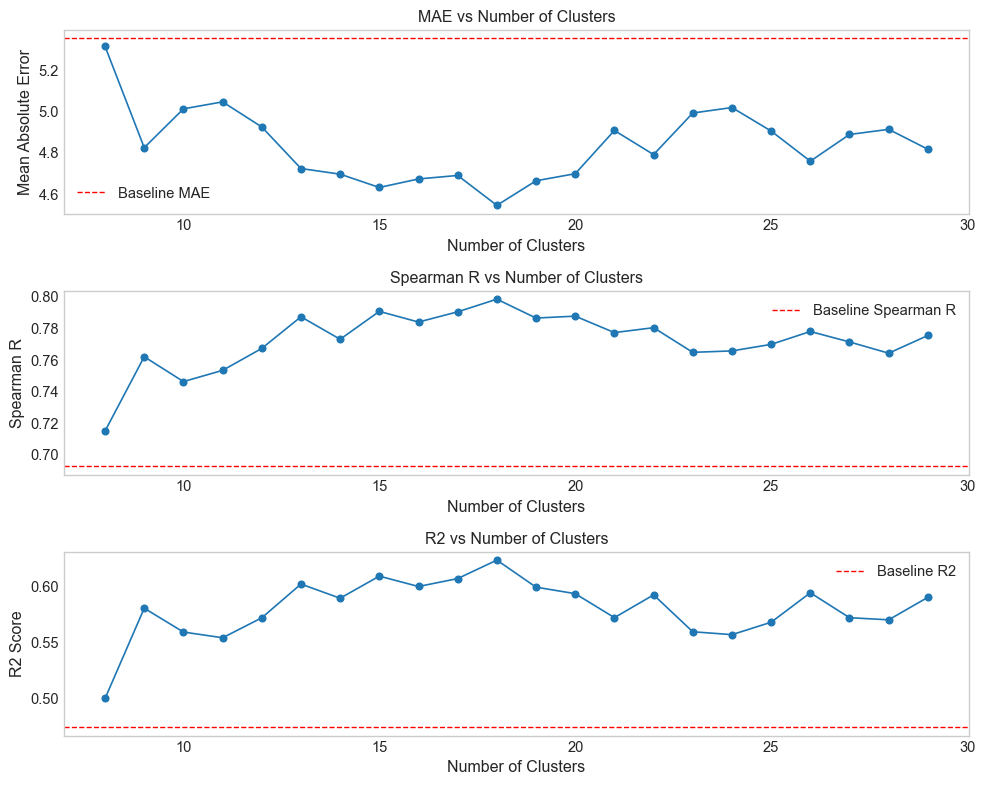

In [151]:
# plot the results
"""0.6925 | MAE: 5.3521 | MAE STD: 4.1145 | R2: 0.4740"""

clusters = [list(r.keys())[0] for r in results]
maes = [list(r.values())[0]['mae'] for r in results]
spearmans = [list(r.values())[0]['spearman'] for r in results]
r2s = [list(r.values())[0]['R2'] for r in results]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(clusters, maes, marker='o')
plt.grid()
plt.axhline(y=5.3521, color='r', linestyle='--', label='Baseline MAE', linewidth=1)
plt.title('MAE vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(clusters, spearmans, marker='o')
plt.grid()
plt.title('Spearman R vs Number of Clusters')
plt.axhline(y=0.6925, color='r', linestyle='--', label='Baseline Spearman R', linewidth=1)
plt.xlabel('Number of Clusters')
plt.ylabel('Spearman R')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(clusters, r2s, marker='o')
plt.grid()
plt.title('R2 vs Number of Clusters')
plt.axhline(y=0.4740, color='r', linestyle='--', label='Baseline R2', linewidth=1)
plt.xlabel('Number of Clusters')
plt.ylabel('R2 Score')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# same but with k means instad of minibatch
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import random

for n_cluster in range(6, 30, 2):
    print("=========", n_cluster, "========")
    for seed in random.sample(range(100), 2):
        print('seed:', seed)
        vocab = KinematicVocabulary(n_clusters=n_cluster, random_state=seed, model_type='kmeans', n_init=10,
                                    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                                    power_feats=None)

        # => either go with this or total_path instead of vel_p90, but not both since they are redundant

        selector = NestedFeatureSelector(
            top_n=6, 
            pr2_threshold=0.05,         # how much additional variance is needed to be selected
            corr_threshold=0.8          # corr threhsold between candiate features to be selected (to avoid redundancy)
        )

        model = LassoCV(alphas=np.logspace(-1, 5, 30))

        #model = ElasticNetCV(alphas=np.logspace(-1, 2, 20))


        results_df, profile_df, _ = run_hybrid_vocabulary_loso(
                    df_videos=df_pc1_features, 
                    df_windows=df_window, 
                    primary_features=pc1_features, 
                    extra_features=['Case_1', 'Case_3'], 
                    target_col='QRS_Overal', 
                    surgeon_col='Participant Number', 
                    video_col='video_id', 
                    vocab=vocab,
                    model=model
        )

========= 6 ========
seed: 0


Running LOSO: 100%|██████████| 28/28 [00:29<00:00,  1.04s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.1278 ± 4.2514
Spearman R: 0.6849
Overall R2: 0.4879
Number of selected features: 6.00 ± 0.00
seed: 28


Running LOSO: 100%|██████████| 28/28 [00:29<00:00,  1.06s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.1259 ± 4.2524
Spearman R: 0.6840
Overall R2: 0.4880
Number of selected features: 6.00 ± 0.00
========= 8 ========
seed: 12


...


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.8411 ± 3.8128
Spearman R: 0.7511
Overall R2: 0.5617
Number of selected features: 26.00 ± 0.00
========= 28 ========
seed: 66


Running LOSO: 100%|██████████| 28/28 [01:29<00:00,  3.18s/it]



=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7504 ± 3.9196
Spearman R: 0.7473
Overall R2: 0.5622
Number of selected features: 28.00 ± 0.00
seed: 59


Running LOSO: 100%|██████████| 28/28 [01:18<00:00,  2.82s/it]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.7851 ± 3.9272
Spearman R: 0.7448
Overall R2: 0.5577
Number of selected features: 28.00 ± 0.00
